In [51]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import re
data_org = pd.read_csv('/Users/meggie/Documents/MoltenSaltPropnet/data/new_data.csv')
import os
import numpy as np

# Output directory for figures
output_dir = os.path.join("additional_data_studies")
os.makedirs(output_dir, exist_ok=True)


In [52]:
data_org.head()

,System,Mol Mass,Mol Frac,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,...,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],symbol,atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
0,AlCl3,133.3405,Pure Salt,465.0,453.0,2.56,0.002710,0.00228,19400.0,NaN,...,"{'Al': 1.61, 'Cl': 3.16}","{'Al': '3+', 'Cl': '1-'}","{'Al': 1.18, 'Cl': 0.79}","{'Al': 1.25, 'Cl': 1.0}","{'Al': 1.18, 'Cl': 0.99}","{'Al': 577.5, 'Cl': 1251.2}","{'Al': 'Al', 'Cl': 'Cl'}",3.55,12.888750,3.222188
1,BeCl2,79.9182,Pure Salt,688.0,760.0,2.28,0.001100,NaN,NaN,NaN,...,"{'Be': 1.57, 'Cl': 3.16}","{'Be': '2+', 'Cl': '1-'}","{'Be': 1.12, 'Cl': 0.79}","{'Be': 1.05, 'Cl': 1.0}","{'Be': 0.9, 'Cl': 0.99}","{'Be': 899.5, 'Cl': 1251.2}","{'Be': 'Be', 'Cl': 'Cl'}",2.70,7.410920,2.470307
2,BeF2,47.0090,Pure Salt,821.2,1442.0,1.97,0.000015,NaN,NaN,-8.120,...,"{'Be': 1.57, 'F': 3.98}","{'Be': '2+', 'F': '1-'}","{'Be': 1.12, 'F': 0.42}","{'Be': 1.05, 'F': 0.5}","{'Be': 0.9, 'F': 0.71}","{'Be': 899.5, 'F': 1681.0}","{'Be': 'Be', 'F': 'F'}",1.96,3.898795,1.299598
3,CaCl2,110.9840,Pure Salt,1045.0,2230.0,2.53,0.000423,NaN,NaN,-0.545,...,"{'Ca': 1.0, 'Cl': 3.16}","{'Ca': '2+', 'Cl': '1-'}","{'Ca': 1.94, 'Cl': 0.79}","{'Ca': 1.8, 'Cl': 1.0}","{'Ca': 1.74, 'Cl': 0.99}","{'Ca': 589.8, 'Cl': 1251.2}","{'Ca': 'Ca', 'Cl': 'Cl'}",3.52,25.583188,8.527729
4,CaF2,78.0748,Pure Salt,1692.0,2724.0,3.18,0.000391,0.10000,47600.0,NaN,...,"{'Ca': 1.0, 'F': 3.98}","{'Ca': '2+', 'F': '1-'}","{'Ca': 1.94, 'F': 0.42}","{'Ca': 1.8, 'F': 0.5}","{'Ca': 1.74, 'F': 0.71}","{'Ca': 589.8, 'F': 1681.0}","{'Ca': 'Ca', 'F': 'F'}",2.78,22.071063,7.357021


In [53]:
pred_cols = data_org.columns[3:16]
data_cols = data_org.columns[17:].drop('symbol')

anion_filter = 'F'
flag = data_org['System'].apply(lambda x: True if anion_filter in x else False)
data = data_org[flag]
data

,System,Mol Mass,Mol Frac,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,...,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],symbol,atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
2,BeF2,47.0090,Pure Salt,821.2,1442.0,1.97000,0.000015,NaN,NaN,-8.12,...,"{'Be': 1.57, 'F': 3.98}","{'Be': '2+', 'F': '1-'}","{'Be': 1.12, 'F': 0.42}","{'Be': 1.05, 'F': 0.5}","{'Be': 0.9, 'F': 0.71}","{'Be': 899.5, 'F': 1681.0}","{'Be': 'Be', 'F': 'F'}",1.96,3.898795,1.299598
4,CaF2,78.0748,Pure Salt,1692.0,2724.0,3.18000,0.000391,0.100000,47600.00,NaN,...,"{'Ca': 1.0, 'F': 3.98}","{'Ca': '2+', 'F': '1-'}","{'Ca': 1.94, 'F': 0.42}","{'Ca': 1.8, 'F': 0.5}","{'Ca': 1.74, 'F': 0.71}","{'Ca': 589.8, 'F': 1681.0}","{'Ca': 'Ca', 'F': 'F'}",2.78,22.071063,7.357021
6,GdF3,214.2452,Pure Salt,1505.0,2550.0,NaN,NaN,NaN,NaN,NaN,...,"{'Gd': 1.2, 'F': 3.98}","{'Gd': '3+', 'F': '1-'}","{'Gd': 2.33, 'F': 0.42}","{'Gd': 1.8, 'F': 0.5}","{'Gd': 1.91, 'F': 0.71}","{'Gd': 593.4, 'F': 1681.0}","{'Gd': 'Gd', 'F': 'F'}",3.59,25.838629,6.459657
8,KF,58.0967,Pure Salt,1131.2,1771.0,2.65000,0.000652,0.107000,23800.00,NaN,...,"{'K': 0.82, 'F': 3.98}","{'K': '1+', 'F': '1-'}","{'K': 2.43, 'F': 0.42}","{'K': 2.2, 'F': 0.5}","{'K': 1.96, 'F': 0.71}","{'K': 418.8, 'F': 1681.0}","{'K': 'K', 'F': 'F'}",2.85,39.873453,19.936727
10,LaF3,195.9007,Pure Salt,1766.0,2600.0,5.79000,0.000682,NaN,NaN,NaN,...,"{'La': 1.1, 'F': 3.98}","{'La': '3+', 'F': '1-'}","{'La': 1.95, 'F': 0.42}","{'La': 1.95, 'F': 0.5}","{'La': 1.69, 'F': 0.71}","{'La': 538.1, 'F': 1681.0}","{'La': 'La', 'F': 'F'}",3.21,35.507359,8.876840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4669,RbBF4,NaN,Pure Salt,NaN,NaN,3.07907,0.001040,NaN,NaN,NaN,...,"{'Rb': 0.82, 'F': 3.98}","{'Rb': '1+', 'F': '1-'}","{'Rb': 2.65, 'F': 0.42}","{'Rb': 2.35, 'F': 0.5}","{'Rb': 2.11, 'F': 0.71}","{'Rb': 403.0, 'F': 1681.0}","{'Rb': 'Rb', 'F': 'F'}",4.33,47.663095,9.532619
4725,RbF,NaN,Pure Salt,NaN,NaN,3.99530,0.001021,0.097107,24324.51,NaN,...,"{'Rb': 0.82, 'F': 3.98}","{'Rb': '1+', 'F': '1-'}","{'Rb': 2.65, 'F': 0.42}","{'Rb': 2.35, 'F': 0.5}","{'Rb': 2.11, 'F': 0.71}","{'Rb': 403.0, 'F': 1681.0}","{'Rb': 'Rb', 'F': 'F'}",3.07,45.548236,22.774118
4794,SrF2,NaN,Pure Salt,NaN,NaN,4.78400,0.000751,NaN,NaN,NaN,...,"{'Sr': 0.95, 'F': 3.98}","{'Sr': '2+', 'F': '1-'}","{'Sr': 2.19, 'F': 0.42}","{'Sr': 2.0, 'F': 0.5}","{'Sr': 1.92, 'F': 0.71}","{'Sr': 549.5, 'F': 1681.0}","{'Sr': 'Sr', 'F': 'F'}",3.03,26.318906,8.772969
4798,ThF4,NaN,Pure Salt,NaN,NaN,7.10800,0.000759,NaN,NaN,NaN,...,"{'Th': 1.3, 'F': 3.98}","{'Th': '4+', 'F': '1-'}","{'Th': 1.8, 'F': 0.42}","{'Th': 1.8, 'F': 0.5}","{'Th': 2.06, 'F': 0.71}","{'Th': 587.0, 'F': 1681.0}","{'Th': 'Th', 'F': 'F'}",3.48,48.655032,9.731006


In [54]:
data[pred_cols].head(10)

,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,mu2_b,mu2_c,k_a,k_b,cp_a,cp_b
2,821.2,1442.0,1.97,0.000015,NaN,NaN,-8.12,11500.0,639000.0,0.801,-0.000002,51.100,0.03460
4,1692.0,2724.0,3.18,0.000391,0.100,47600.0,NaN,NaN,NaN,0.667,-0.000060,99.914,NaN
6,1505.0,2550.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1131.2,1771.0,2.65,0.000652,0.107,23800.0,NaN,NaN,NaN,0.855,-0.000254,71.965,NaN
10,1766.0,2600.0,5.79,0.000682,NaN,NaN,NaN,NaN,NaN,NaN,NaN,135.000,NaN
12,1121.2,1943.0,2.37,0.000500,0.115,27000.0,NaN,NaN,NaN,1.880,-0.000399,64.183,NaN
14,1534.2,2512.0,3.24,0.000524,0.187,32100.0,NaN,NaN,NaN,0.867,-0.000141,NaN,NaN
16,1268.0,1978.0,2.76,0.000636,0.120,26500.0,NaN,NaN,NaN,1.260,-0.000280,72.989,NaN
18,1650.0,2573.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,184.000,-0.00444
20,1735.0,2500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [55]:
data[data_cols].head(10)

,polarizability_element[10-24Cm3],atomic_mass_element,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
2,"{'Be': 5.6, 'F': 0.557}","{'Be': 9.012, 'F': 18.998}","{'Be': 1.57, 'F': 3.98}","{'Be': '2+', 'F': '1-'}","{'Be': 1.12, 'F': 0.42}","{'Be': 1.05, 'F': 0.5}","{'Be': 0.9, 'F': 0.71}","{'Be': 899.5, 'F': 1681.0}",1.96,3.898795,1.299598
4,"{'Ca': 25.0, 'F': 0.557}","{'Ca': 40.078, 'F': 18.998}","{'Ca': 1.0, 'F': 3.98}","{'Ca': '2+', 'F': '1-'}","{'Ca': 1.94, 'F': 0.42}","{'Ca': 1.8, 'F': 0.5}","{'Ca': 1.74, 'F': 0.71}","{'Ca': 589.8, 'F': 1681.0}",2.78,22.071063,7.357021
6,"{'Gd': 26.0, 'F': 0.557}","{'Gd': 157.25, 'F': 18.998}","{'Gd': 1.2, 'F': 3.98}","{'Gd': '3+', 'F': '1-'}","{'Gd': 2.33, 'F': 0.42}","{'Gd': 1.8, 'F': 0.5}","{'Gd': 1.91, 'F': 0.71}","{'Gd': 593.4, 'F': 1681.0}",3.59,25.838629,6.459657
8,"{'K': 43.4, 'F': 0.557}","{'K': 39.098, 'F': 18.998}","{'K': 0.82, 'F': 3.98}","{'K': '1+', 'F': '1-'}","{'K': 2.43, 'F': 0.42}","{'K': 2.2, 'F': 0.5}","{'K': 1.96, 'F': 0.71}","{'K': 418.8, 'F': 1681.0}",2.85,39.873453,19.936727
10,"{'La': 37.0, 'F': 0.557}","{'La': 138.905, 'F': 18.998}","{'La': 1.1, 'F': 3.98}","{'La': '3+', 'F': '1-'}","{'La': 1.95, 'F': 0.42}","{'La': 1.95, 'F': 0.5}","{'La': 1.69, 'F': 0.71}","{'La': 538.1, 'F': 1681.0}",3.21,35.507359,8.876840
12,"{'Li': 24.3, 'F': 0.557}","{'Li': 6.941, 'F': 18.998}","{'Li': 0.98, 'F': 3.98}","{'Li': '1+', 'F': '1-'}","{'Li': 1.67, 'F': 0.42}","{'Li': 1.45, 'F': 0.5}","{'Li': 1.34, 'F': 0.71}","{'Li': 520.2, 'F': 1681.0}",2.09,14.373703,7.186852
14,"{'Mg': 10.6, 'F': 0.557}","{'Mg': 24.305, 'F': 18.998}","{'Mg': 1.31, 'F': 3.98}","{'Mg': '2+', 'F': '1-'}","{'Mg': 1.45, 'F': 0.42}","{'Mg': 1.5, 'F': 0.5}","{'Mg': 1.3, 'F': 0.71}","{'Mg': 737.7, 'F': 1681.0}",2.29,9.197661,3.065887
16,"{'Na': 23.6, 'F': 0.557}","{'Na': 22.99, 'F': 18.998}","{'Na': 0.93, 'F': 3.98}","{'Na': '1+', 'F': '1-'}","{'Na': 1.9, 'F': 0.42}","{'Na': 1.8, 'F': 0.5}","{'Na': 1.54, 'F': 0.71}","{'Na': 495.8, 'F': 1681.0}",2.32,20.535509,10.267754
18,"{'Nd': 32.0, 'F': 0.557}","{'Nd': 144.242, 'F': 18.998}","{'Nd': 1.14, 'F': 3.98}","{'Nd': '3+, 4+', 'F': '1-'}","{'Nd': 2.06, 'F': 0.42}","{'Nd': 1.85, 'F': 0.5}","{'Nd': 1.94, 'F': 0.71}","{'Nd': 533.1, 'F': 1681.0}",3.32,34.114859,8.528715
20,"{'Np': 45.0, 'F': 0.557}","{'Np': 237.0, 'F': 18.998}","{'Np': 1.36, 'F': 3.98}","{'Np': '5+', 'F': '1-'}","{'Np': 1.75, 'F': 0.42}","{'Np': 1.75, 'F': 0.5}","{'Np': 1.9, 'F': 0.71}","{'Np': 604.5, 'F': 1681.0}",3.01,42.640161,10.660040


# Study for all F 


================ polarizability_element[10-24Cm3] ================



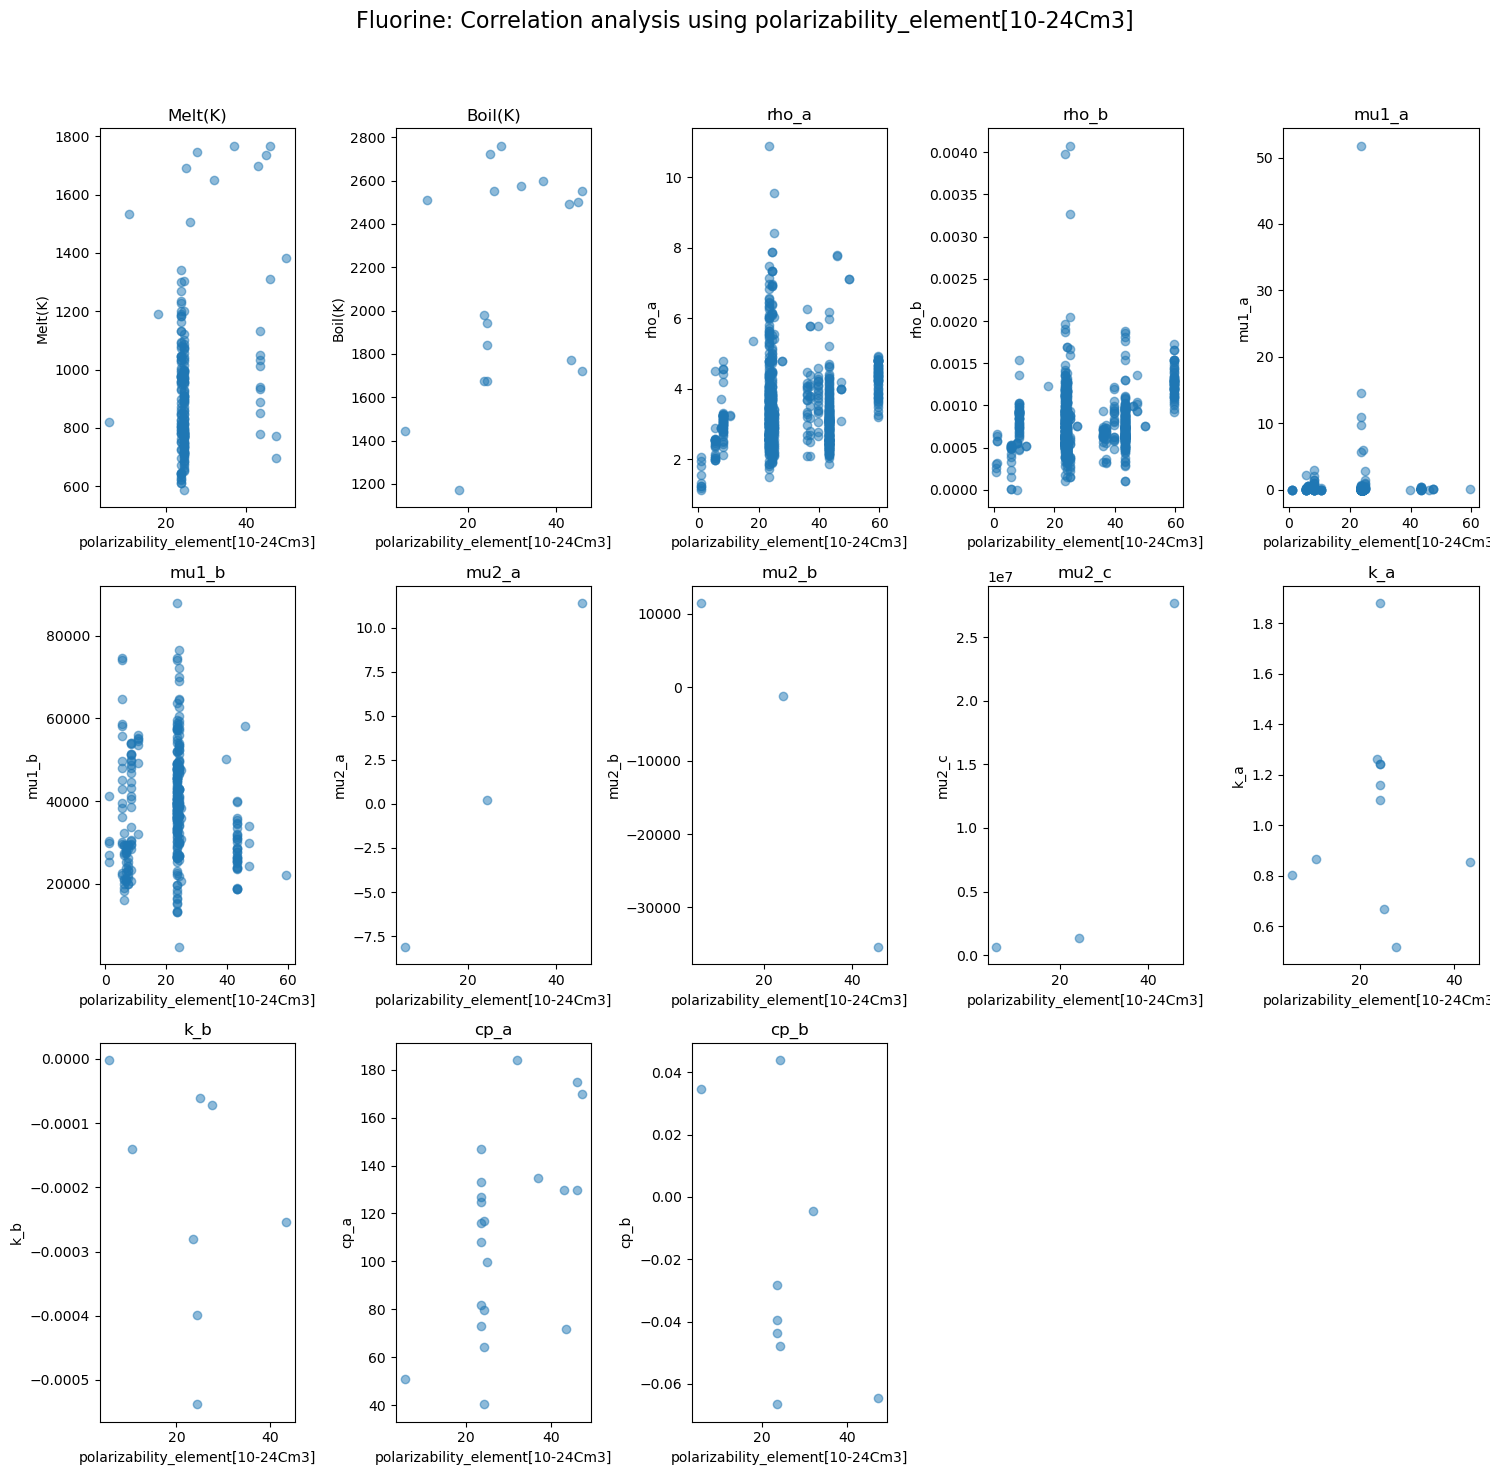

Correlation table:
         Correlation
Melt(K)     0.287538
Boil(K)     0.333411
rho_a       0.146587
rho_b       0.272794
mu1_a      -0.006085
mu1_b      -0.065233
mu2_a       0.999144
mu2_b      -0.976786
mu2_c       0.897071
k_a         0.036692
k_b        -0.350915
cp_a        0.537133
cp_b       -0.521288

================ atomic_mass_element ================



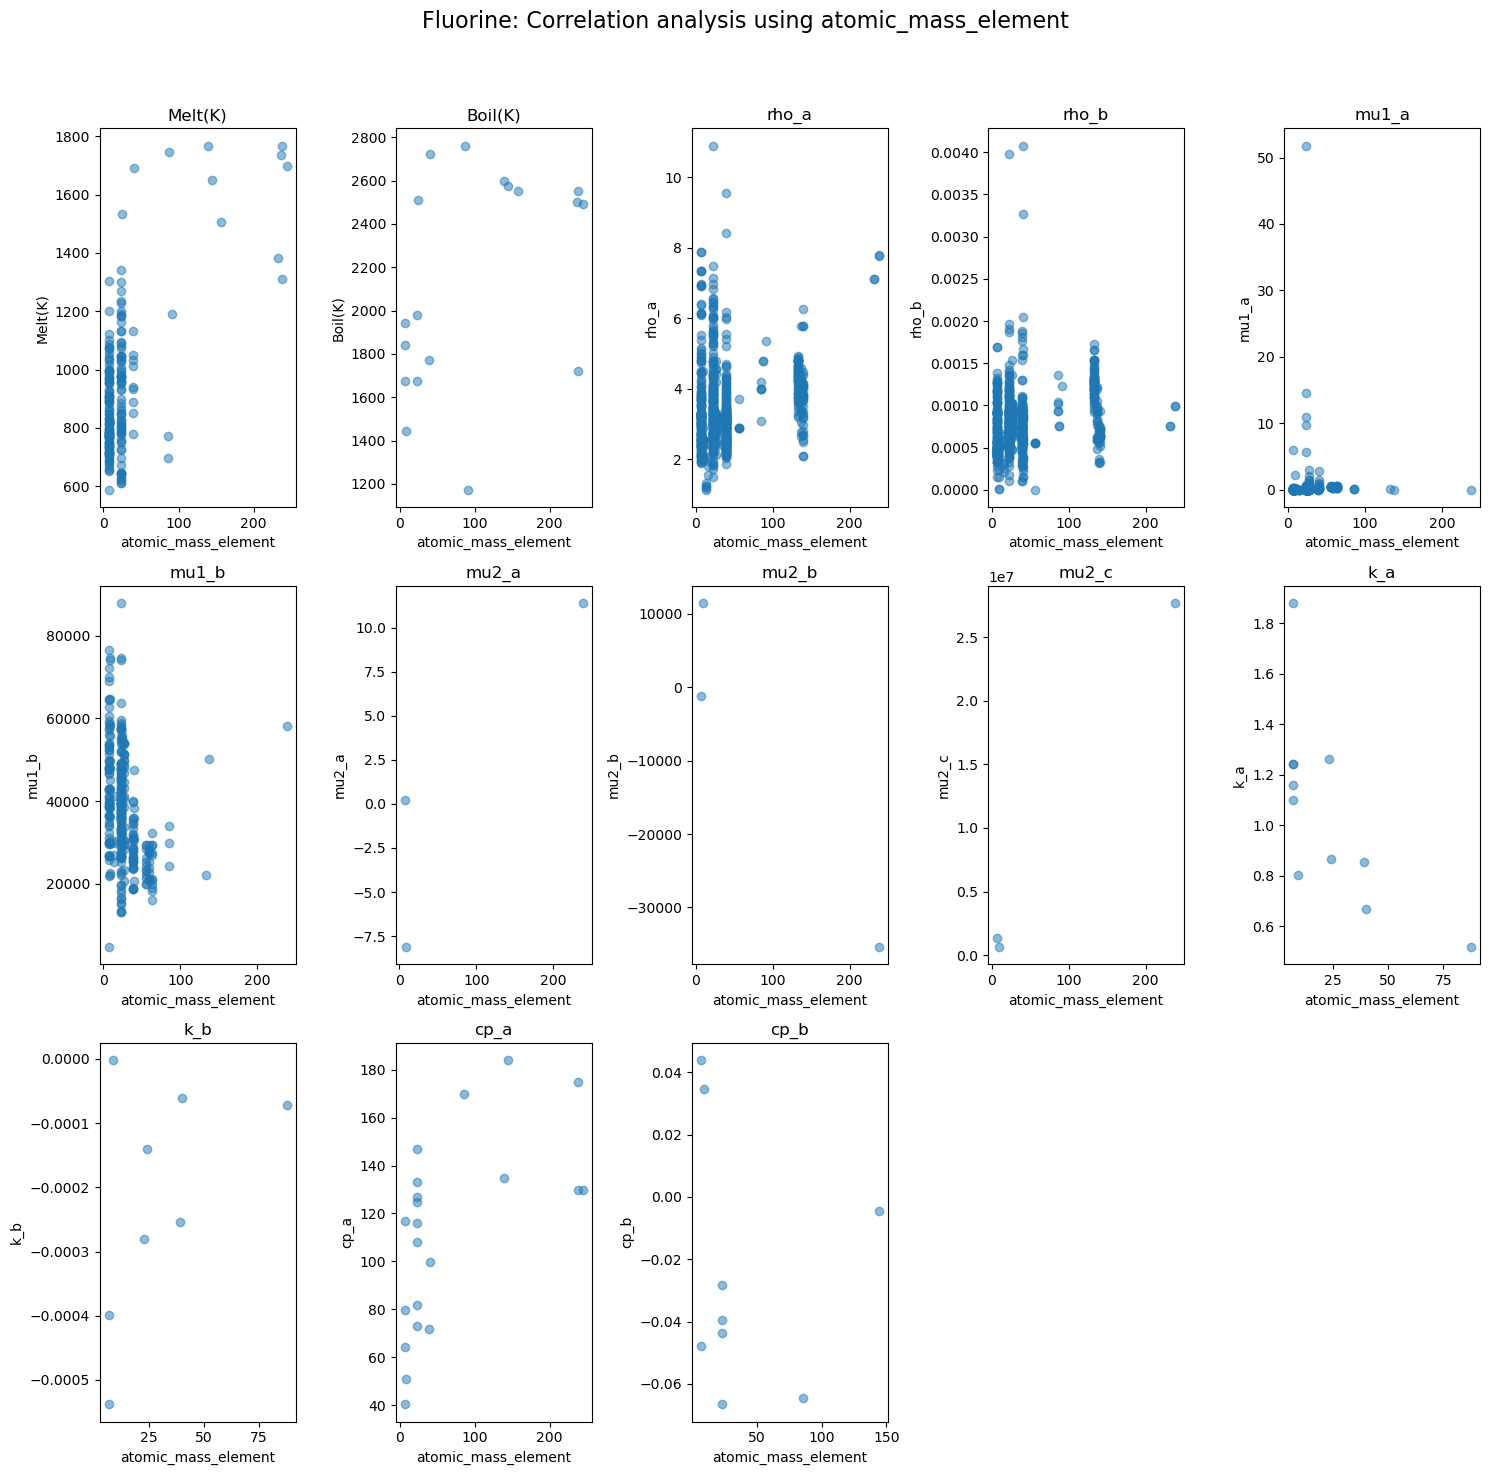

Correlation table:
         Correlation
Melt(K)     0.620871
Boil(K)     0.414541
rho_a       0.248885
rho_b       0.253921
mu1_a      -0.001531
mu1_b      -0.297410
mu2_a       0.901670
mu2_b      -0.963059
mu2_c       0.999524
k_a        -0.678389
k_b         0.477907
cp_a        0.580996
cp_b       -0.111864

================ electronegativity_element ================



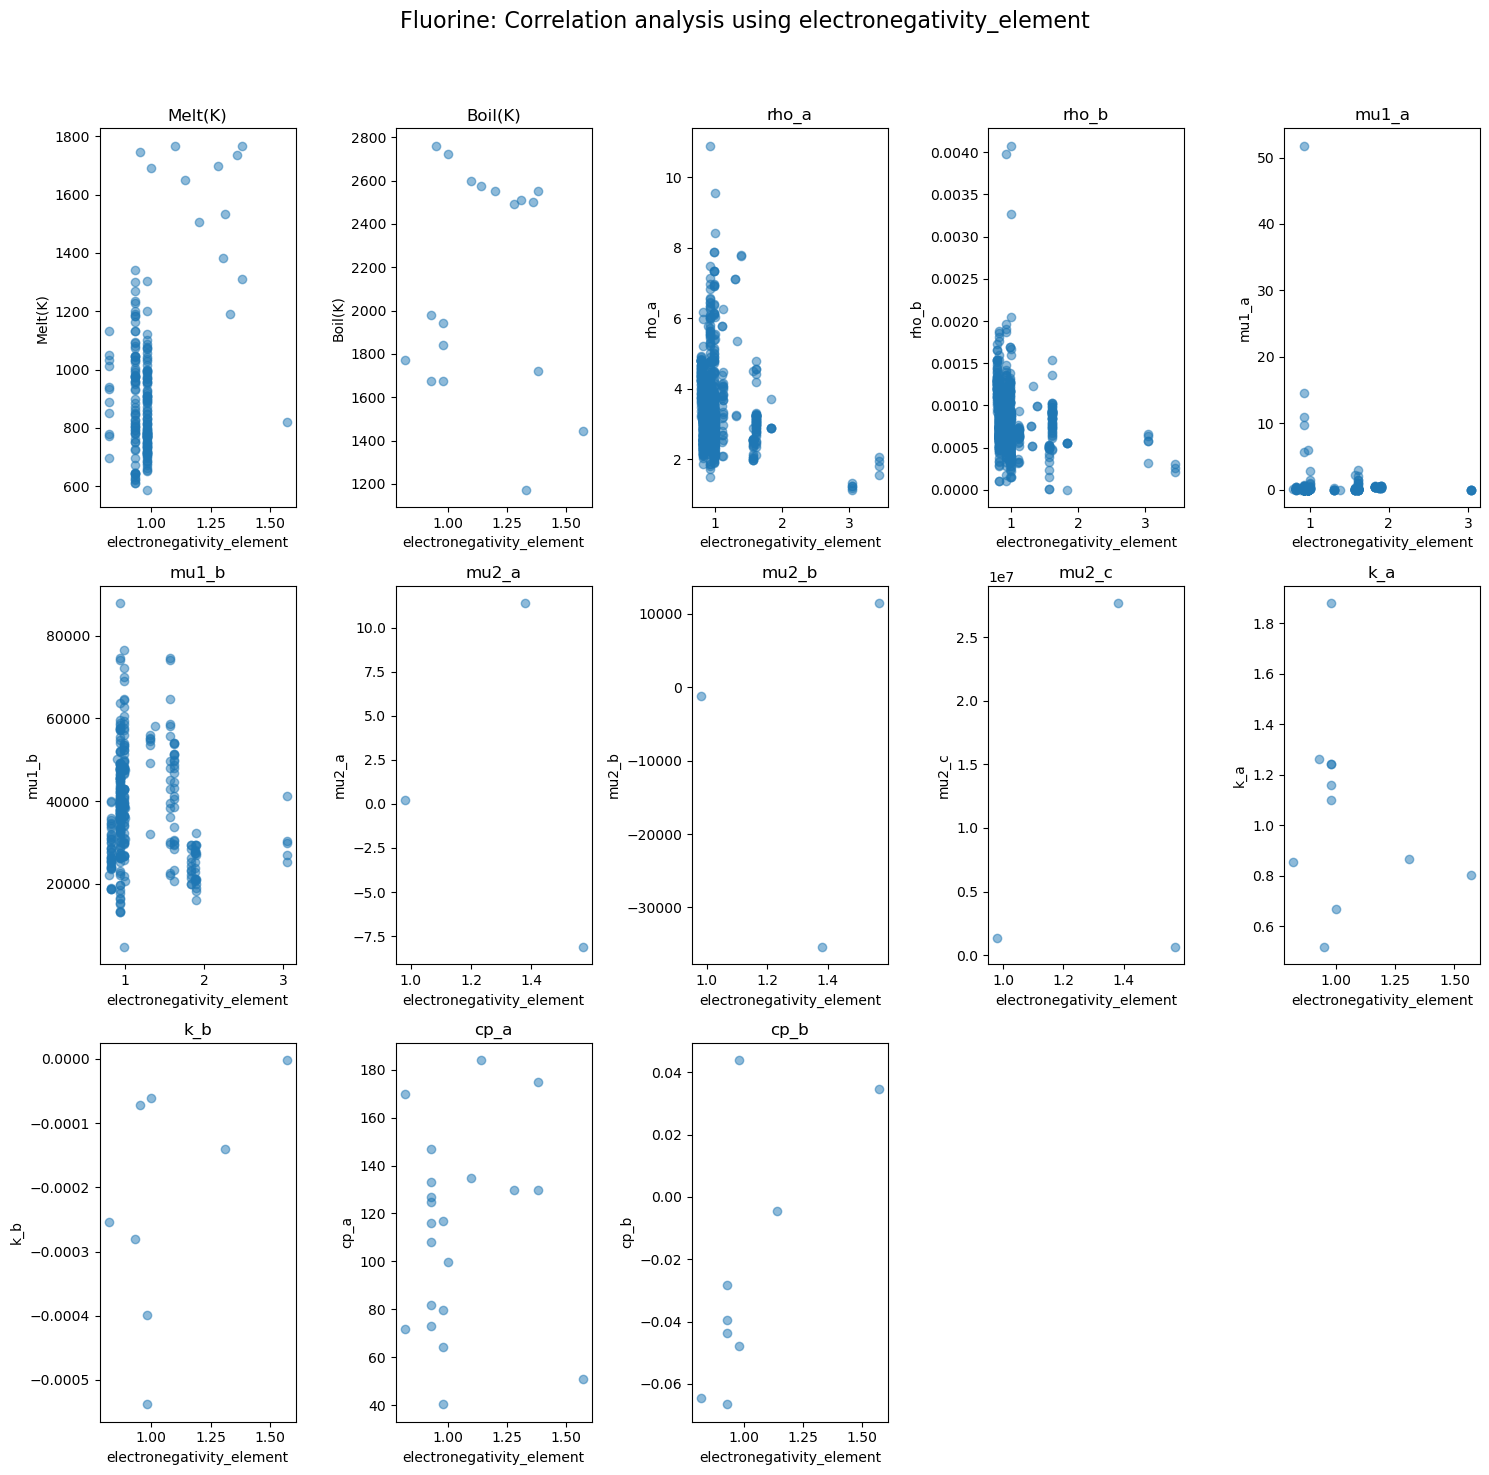

Correlation table:
         Correlation
Melt(K)     0.405067
Boil(K)    -0.046721
rho_a      -0.170670
rho_b      -0.168426
mu1_a      -0.023046
mu1_b      -0.147493
mu2_a      -0.234504
mu2_b       0.062145
mu2_c       0.178659
k_a        -0.230980
k_b         0.504272
cp_a        0.073639
cp_b        0.673903

================ atomic_radius_element[Angstrom] ================



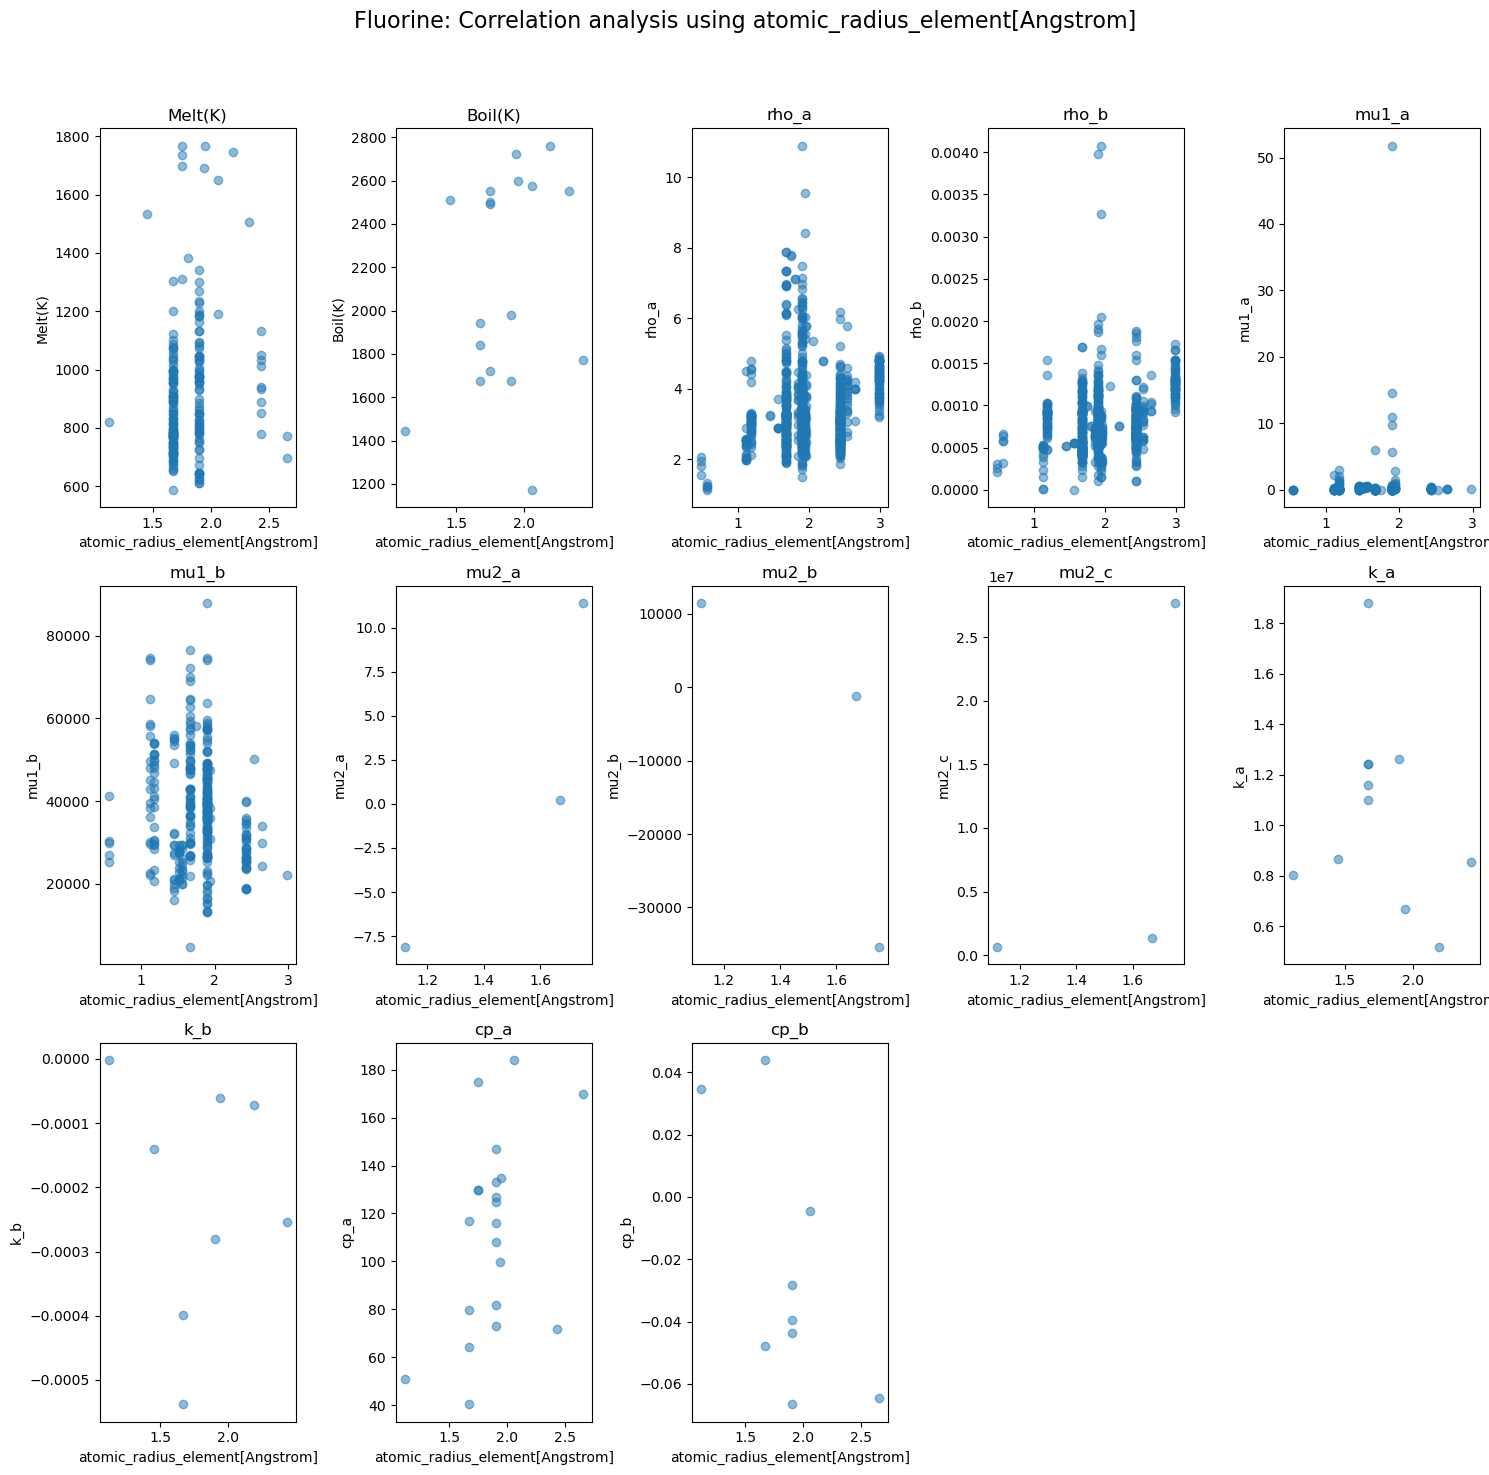

Correlation table:
         Correlation
Melt(K)     0.173488
Boil(K)     0.235149
rho_a       0.142156
rho_b       0.293558
mu1_a       0.015776
mu1_b      -0.167846
mu2_a       0.881899
mu2_b      -0.786642
mu2_c       0.615912
k_a        -0.234850
k_b        -0.109776
cp_a        0.427372
cp_b       -0.639480

================ ionic_radius_element[Angstrom] ================



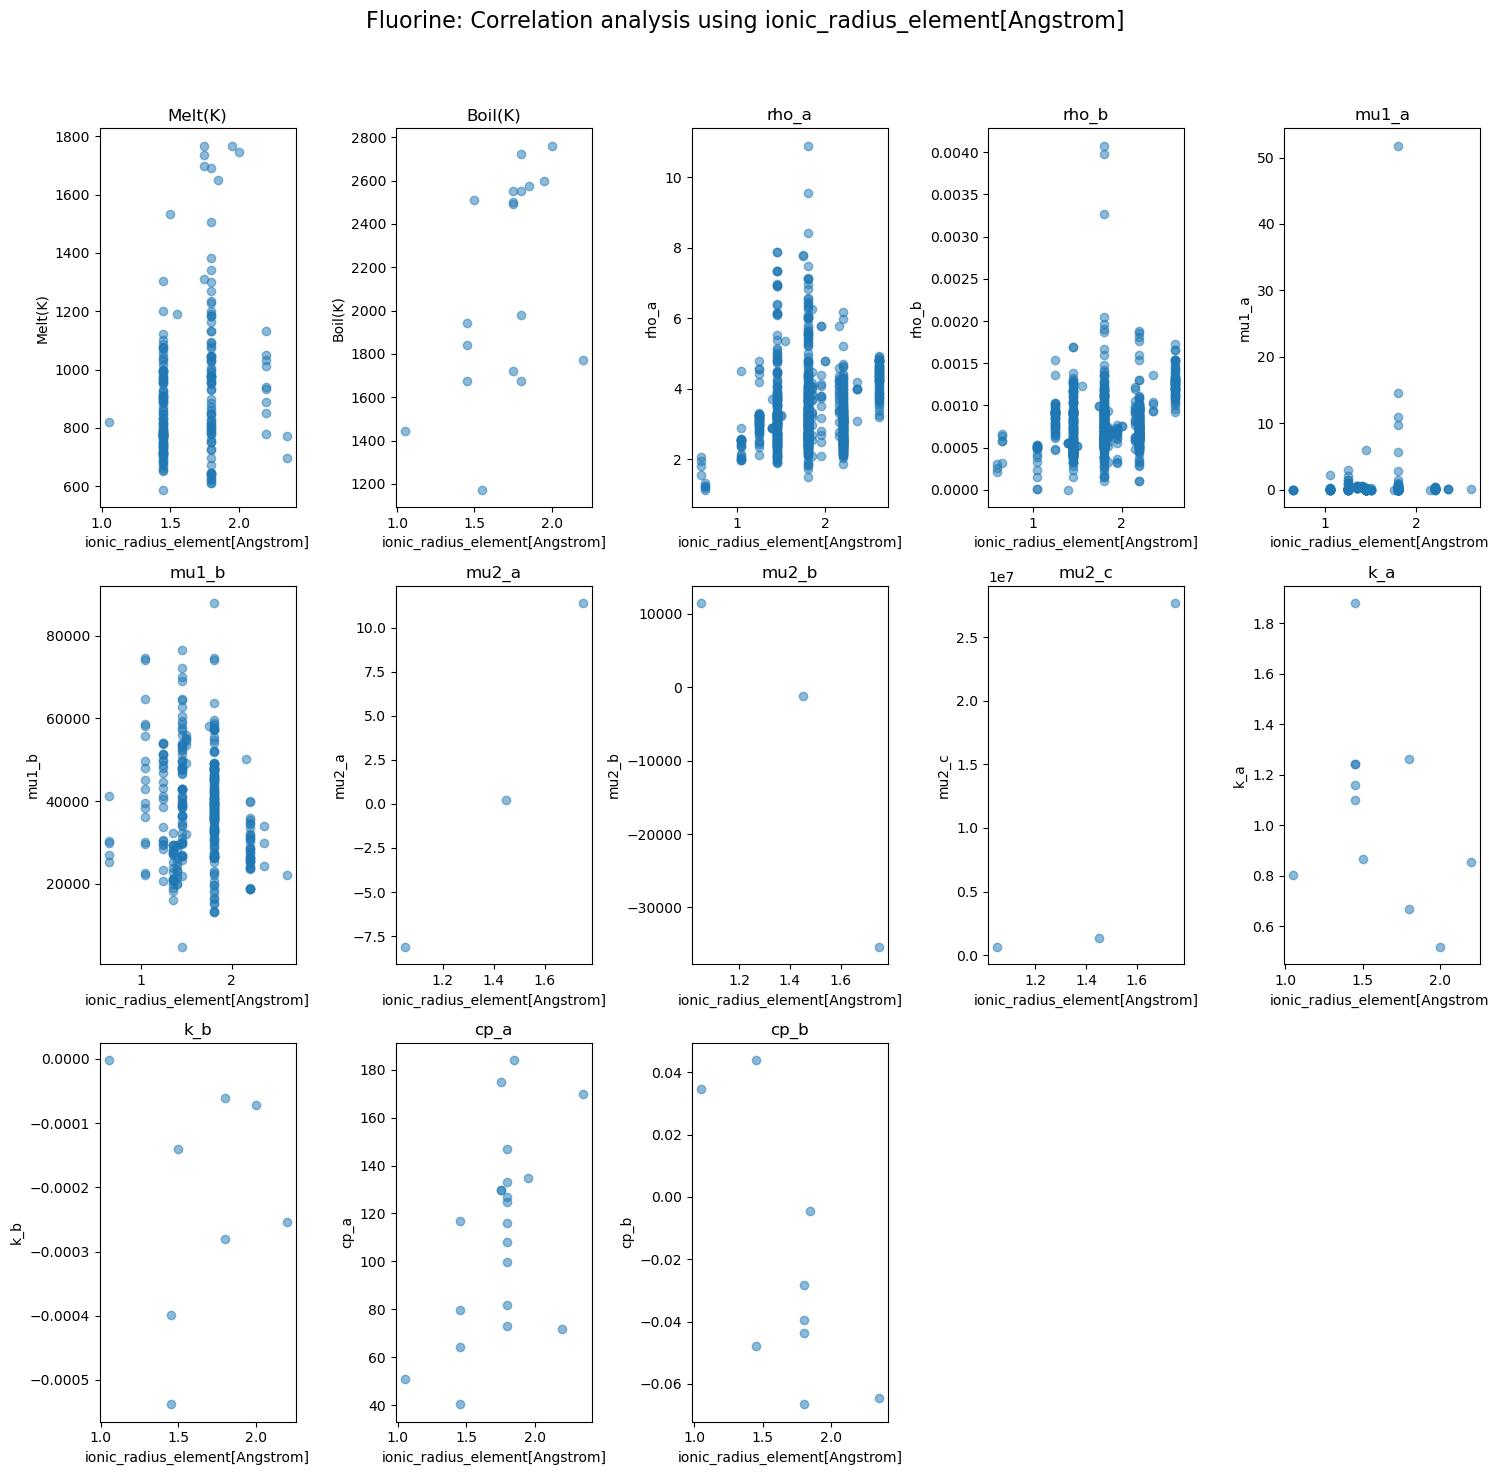

Correlation table:
         Correlation
Melt(K)     0.244025
Boil(K)     0.465236
rho_a       0.137154
rho_b       0.290049
mu1_a       0.026429
mu1_b      -0.160637
mu2_a       0.986170
mu2_b      -0.942411
mu2_c       0.834904
k_a        -0.348478
k_b         0.009761
cp_a        0.528431
cp_b       -0.694228

================ covalent_radius_element[Angstrom] ================



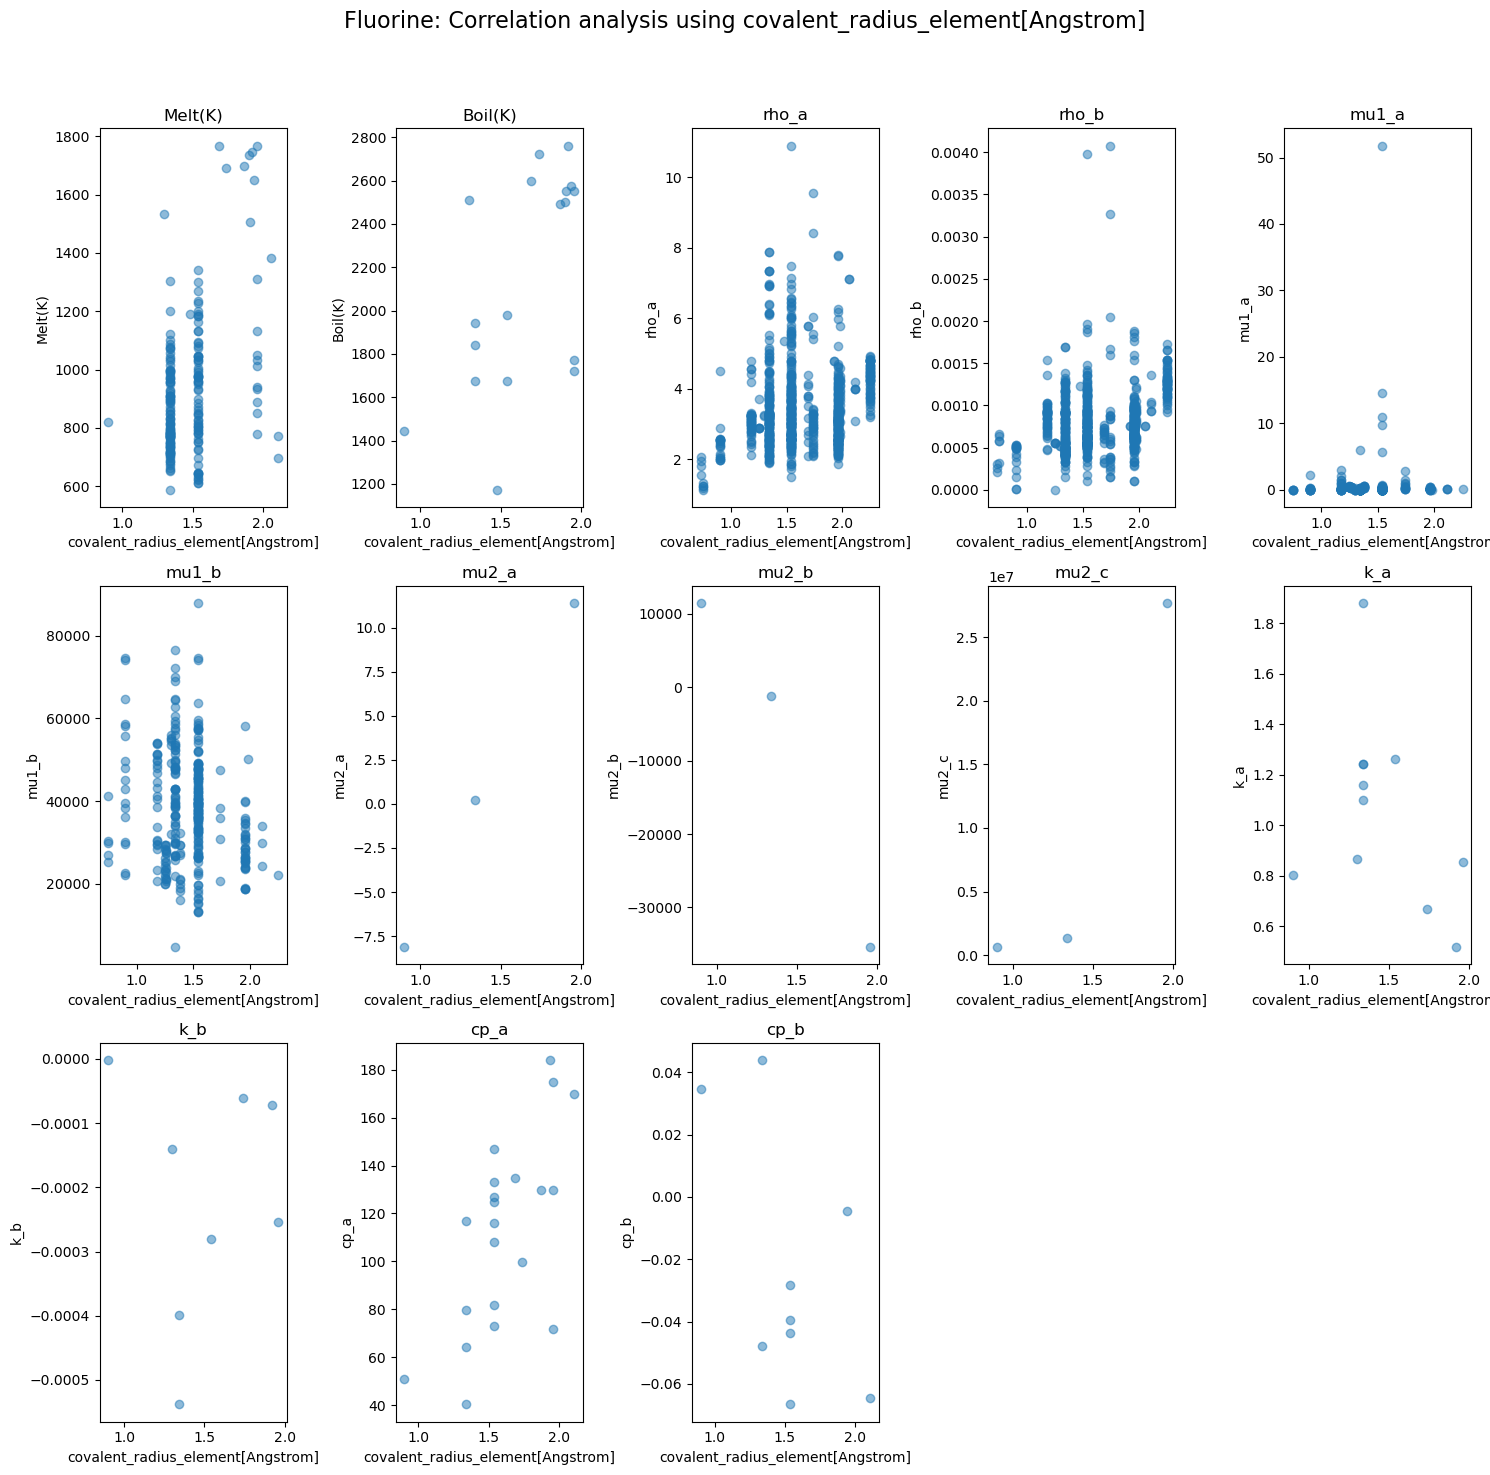

Correlation table:
         Correlation
Melt(K)     0.418981
Boil(K)     0.549475
rho_a       0.146332
rho_b       0.279771
mu1_a       0.016055
mu1_b      -0.200387
mu2_a       0.999909
mu2_b      -0.987066
mu2_c       0.919960
k_a        -0.372477
k_b         0.032690
cp_a        0.667407
cp_b       -0.545356

================ first_ionization_energy[kJ_per_mol] ================



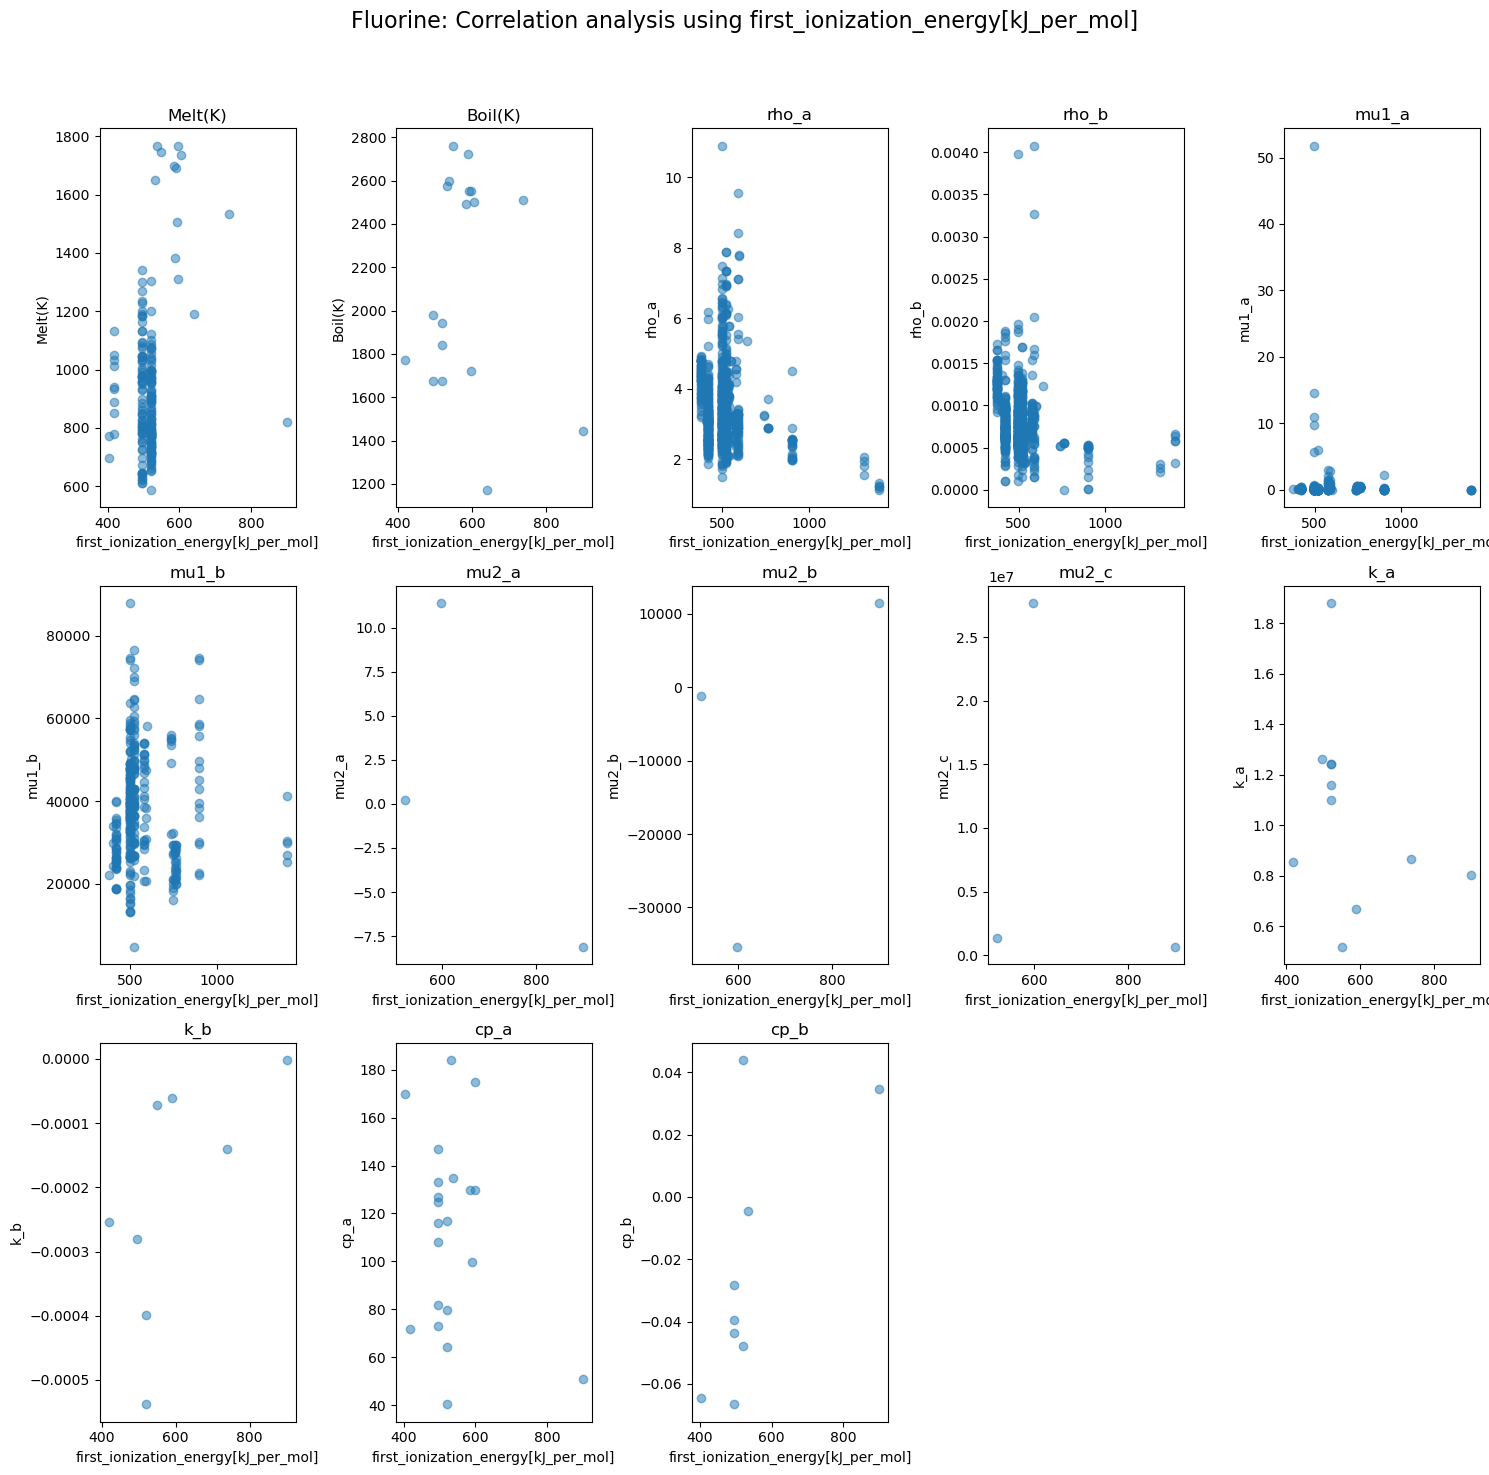

Correlation table:
         Correlation
Melt(K)     0.257752
Boil(K)    -0.101072
rho_a      -0.183989
rho_b      -0.245767
mu1_a      -0.025090
mu1_b      -0.041302
mu2_a      -0.695177
mu2_b       0.559798
mu2_c      -0.345089
k_a        -0.329788
k_b         0.596775
cp_a       -0.235275
cp_b        0.645535

================ COMBINED CORRELATION MATRIX ================

        polarizability_element[10-24Cm3] atomic_mass_element  \
                             Correlation         Correlation   
Melt(K)                         0.287538            0.620871   
Boil(K)                         0.333411            0.414541   
rho_a                           0.146587            0.248885   
rho_b                           0.272794            0.253921   
mu1_a                          -0.006085           -0.001531   
mu1_b                          -0.065233           -0.297410   
mu2_a                           0.999144            0.901670   
mu2_b                          -0.976786       

In [68]:

data_cols = [
    "polarizability_element[10-24Cm3]",
    "atomic_mass_element",
    "electronegativity_element",
    "atomic_radius_element[Angstrom]",
    "ionic_radius_element[Angstrom]",
    "covalent_radius_element[Angstrom]",
    "first_ionization_energy[kJ_per_mol]"
]

pred_cols = [
    "Melt(K)", "Boil(K)", "rho_a", "rho_b",
    "mu1_a", "mu1_b", "mu2_a", "mu2_b",
    "mu2_c", "k_a", "k_b", "cp_a", "cp_b"
]

tgt = data[pred_cols]

# =========================================================
# SAFE EVAL
# =========================================================
def safe_eval(x):
    if pd.isna(x):
        return np.nan
    try:
        value = ast.literal_eval(x)
        if not isinstance(value, dict):
            return np.nan

        cats = [k for k in value.keys() if k != "F"]
        if not cats:
            return np.nan

        return float(value[cats[0]])
    except Exception:
        return np.nan

# =========================================================
# CORRELATION ANALYSIS
# =========================================================
all_correlation_tables = {}

for atomic_col in data_cols:

    print(f"\n================ {atomic_col} ================\n")

    pred = data[atomic_col].apply(safe_eval)

    n_cols = 5
    n_rows = (len(tgt.columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    correlation_table = pd.DataFrame(
        index=tgt.columns,
        columns=["Correlation"],
        dtype=float
    )

    for i, target in enumerate(tgt.columns):

        mask = pred.notna() & tgt[target].notna()
        x = pred[mask]
        y = tgt[target][mask]

        if len(x) < 3:
            axes[i].set_title(f"{target}\n(insufficient data)")
            axes[i].axis("off")
            continue

        axes[i].scatter(x, y, alpha=0.5)
        axes[i].set_xlabel(atomic_col)
        axes[i].set_ylabel(target)
        axes[i].set_title(target)

        correlation_table.loc[target, "Correlation"] = x.corr(y)

    # remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # -------- TITLE --------
    fig.suptitle(
        f"Fluorine: Correlation analysis using {atomic_col}",
        fontsize=16,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # -------- DISPLAY --------
    plt.show()

    # -------- SAVE --------
    safe_name = (
        atomic_col
        .replace("[", "")
        .replace("]", "")
        .replace("/", "_")
        .replace(" ", "_")
    )

    file_path = os.path.join(
        output_dir,
        f"Fluorine: correlation_{safe_name}.png"
    )

    fig.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print("Correlation table:")
    print(correlation_table)

    all_correlation_tables[atomic_col] = correlation_table

# =========================================================
# COMBINED CORRELATION MATRIX
# =========================================================
combined_correlation = pd.concat(all_correlation_tables, axis=1)

print("\n================ COMBINED CORRELATION MATRIX ================\n")
print(combined_correlation)


In [57]:
pred_cols = data_org.columns[3:16]
data_cols = data_org.columns[17:].drop('symbol')

anion_filter = 'F'
flag = data_org['System'].apply(lambda x: True if anion_filter in x else False)
data_clorine = data_org[flag]
data_clorine

,System,Mol Mass,Mol Frac,Melt(K),Boil(K),rho_a,rho_b,mu1_a,mu1_b,mu2_a,...,electronegativity_element,ionic_charge_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],covalent_radius_element[Angstrom],first_ionization_energy[kJ_per_mol],symbol,atomic_radius_components[Angstrom],ionic_polarizability_sum_components,ionic_polarizability_mean_components
2,BeF2,47.0090,Pure Salt,821.2,1442.0,1.97000,0.000015,NaN,NaN,-8.12,...,"{'Be': 1.57, 'F': 3.98}","{'Be': '2+', 'F': '1-'}","{'Be': 1.12, 'F': 0.42}","{'Be': 1.05, 'F': 0.5}","{'Be': 0.9, 'F': 0.71}","{'Be': 899.5, 'F': 1681.0}","{'Be': 'Be', 'F': 'F'}",1.96,3.898795,1.299598
4,CaF2,78.0748,Pure Salt,1692.0,2724.0,3.18000,0.000391,0.100000,47600.00,NaN,...,"{'Ca': 1.0, 'F': 3.98}","{'Ca': '2+', 'F': '1-'}","{'Ca': 1.94, 'F': 0.42}","{'Ca': 1.8, 'F': 0.5}","{'Ca': 1.74, 'F': 0.71}","{'Ca': 589.8, 'F': 1681.0}","{'Ca': 'Ca', 'F': 'F'}",2.78,22.071063,7.357021
6,GdF3,214.2452,Pure Salt,1505.0,2550.0,NaN,NaN,NaN,NaN,NaN,...,"{'Gd': 1.2, 'F': 3.98}","{'Gd': '3+', 'F': '1-'}","{'Gd': 2.33, 'F': 0.42}","{'Gd': 1.8, 'F': 0.5}","{'Gd': 1.91, 'F': 0.71}","{'Gd': 593.4, 'F': 1681.0}","{'Gd': 'Gd', 'F': 'F'}",3.59,25.838629,6.459657
8,KF,58.0967,Pure Salt,1131.2,1771.0,2.65000,0.000652,0.107000,23800.00,NaN,...,"{'K': 0.82, 'F': 3.98}","{'K': '1+', 'F': '1-'}","{'K': 2.43, 'F': 0.42}","{'K': 2.2, 'F': 0.5}","{'K': 1.96, 'F': 0.71}","{'K': 418.8, 'F': 1681.0}","{'K': 'K', 'F': 'F'}",2.85,39.873453,19.936727
10,LaF3,195.9007,Pure Salt,1766.0,2600.0,5.79000,0.000682,NaN,NaN,NaN,...,"{'La': 1.1, 'F': 3.98}","{'La': '3+', 'F': '1-'}","{'La': 1.95, 'F': 0.42}","{'La': 1.95, 'F': 0.5}","{'La': 1.69, 'F': 0.71}","{'La': 538.1, 'F': 1681.0}","{'La': 'La', 'F': 'F'}",3.21,35.507359,8.876840
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4669,RbBF4,NaN,Pure Salt,NaN,NaN,3.07907,0.001040,NaN,NaN,NaN,...,"{'Rb': 0.82, 'F': 3.98}","{'Rb': '1+', 'F': '1-'}","{'Rb': 2.65, 'F': 0.42}","{'Rb': 2.35, 'F': 0.5}","{'Rb': 2.11, 'F': 0.71}","{'Rb': 403.0, 'F': 1681.0}","{'Rb': 'Rb', 'F': 'F'}",4.33,47.663095,9.532619
4725,RbF,NaN,Pure Salt,NaN,NaN,3.99530,0.001021,0.097107,24324.51,NaN,...,"{'Rb': 0.82, 'F': 3.98}","{'Rb': '1+', 'F': '1-'}","{'Rb': 2.65, 'F': 0.42}","{'Rb': 2.35, 'F': 0.5}","{'Rb': 2.11, 'F': 0.71}","{'Rb': 403.0, 'F': 1681.0}","{'Rb': 'Rb', 'F': 'F'}",3.07,45.548236,22.774118
4794,SrF2,NaN,Pure Salt,NaN,NaN,4.78400,0.000751,NaN,NaN,NaN,...,"{'Sr': 0.95, 'F': 3.98}","{'Sr': '2+', 'F': '1-'}","{'Sr': 2.19, 'F': 0.42}","{'Sr': 2.0, 'F': 0.5}","{'Sr': 1.92, 'F': 0.71}","{'Sr': 549.5, 'F': 1681.0}","{'Sr': 'Sr', 'F': 'F'}",3.03,26.318906,8.772969
4798,ThF4,NaN,Pure Salt,NaN,NaN,7.10800,0.000759,NaN,NaN,NaN,...,"{'Th': 1.3, 'F': 3.98}","{'Th': '4+', 'F': '1-'}","{'Th': 1.8, 'F': 0.42}","{'Th': 1.8, 'F': 0.5}","{'Th': 2.06, 'F': 0.71}","{'Th': 587.0, 'F': 1681.0}","{'Th': 'Th', 'F': 'F'}",3.48,48.655032,9.731006



================ polarizability_element[10-24Cm3] ================



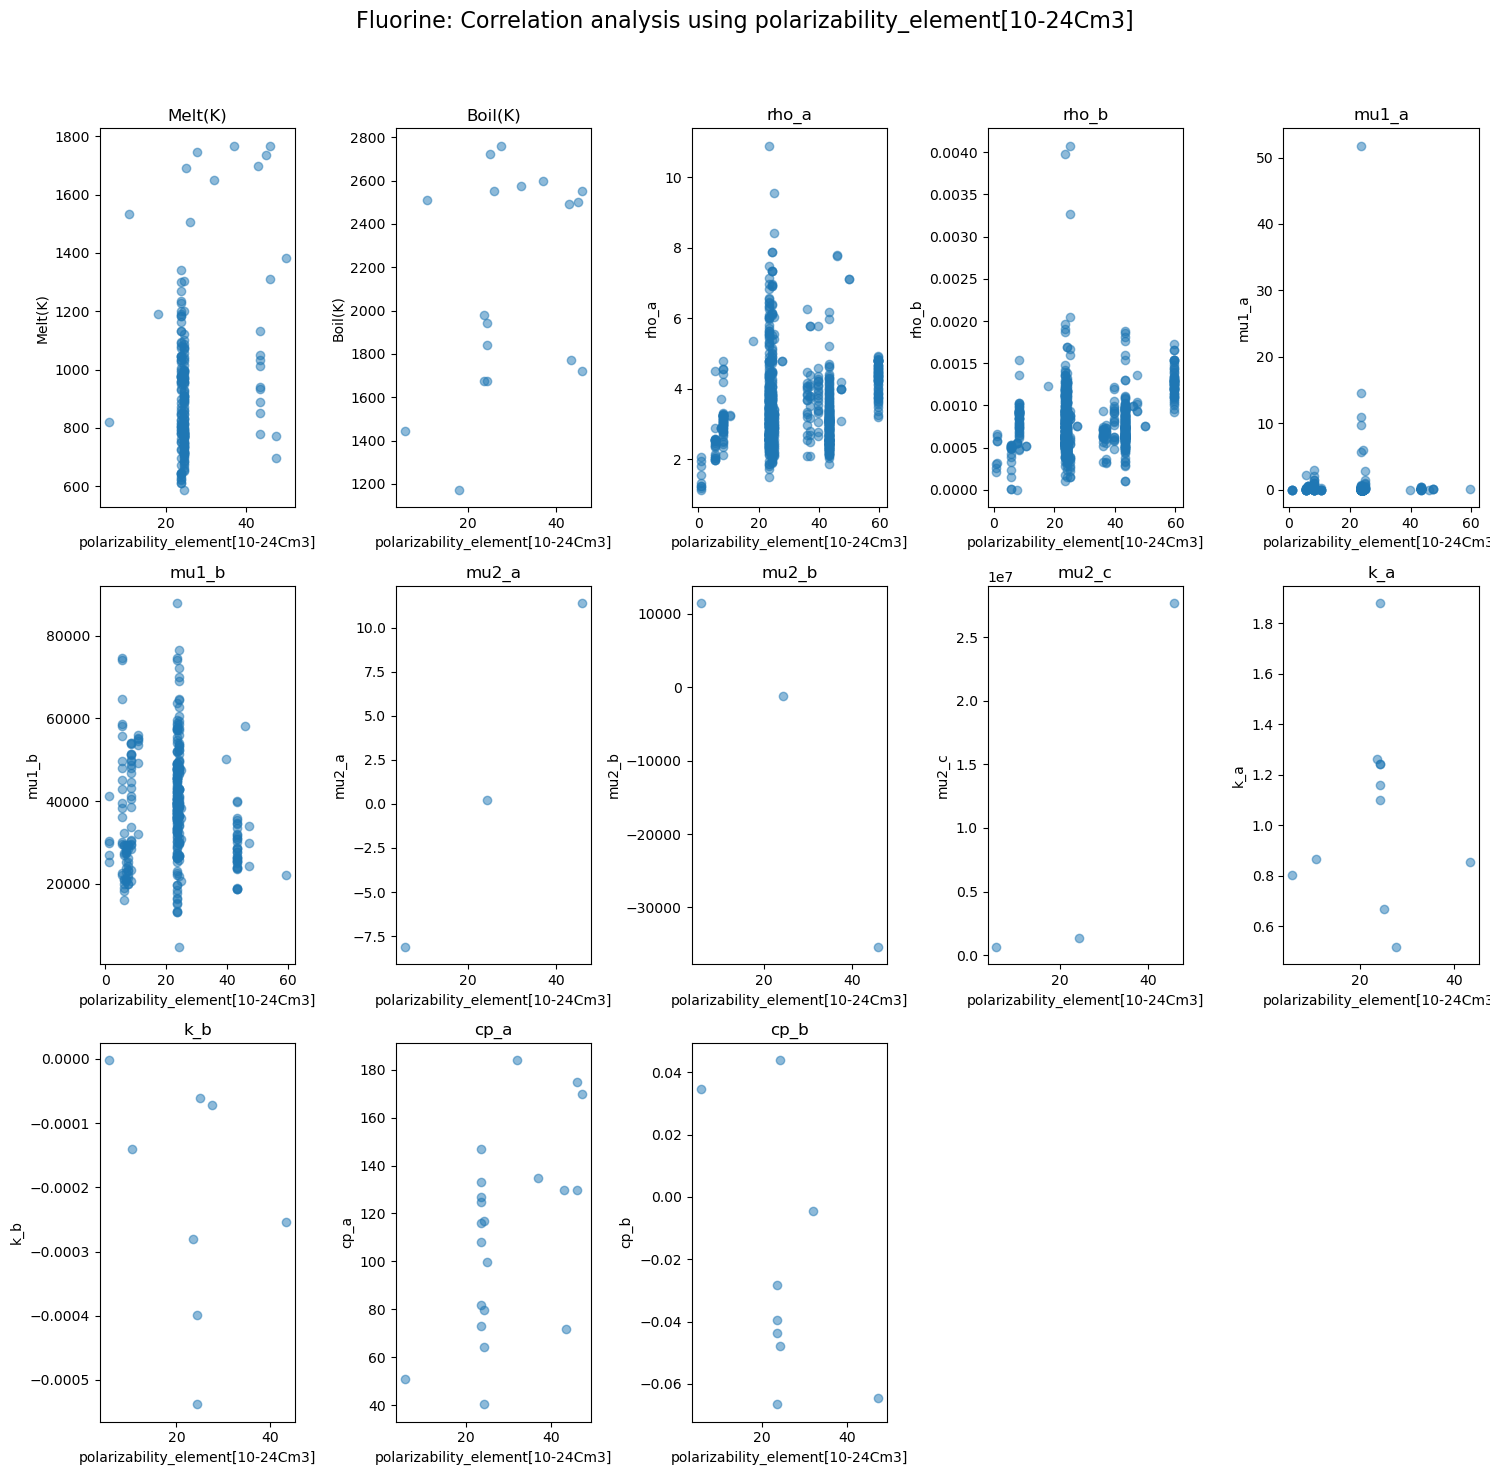

Correlation table:
         Correlation
Melt(K)     0.287538
Boil(K)     0.333411
rho_a       0.146587
rho_b       0.272794
mu1_a      -0.006085
mu1_b      -0.065233
mu2_a       0.999144
mu2_b      -0.976786
mu2_c       0.897071
k_a         0.036692
k_b        -0.350915
cp_a        0.537133
cp_b       -0.521288

================ atomic_mass_element ================



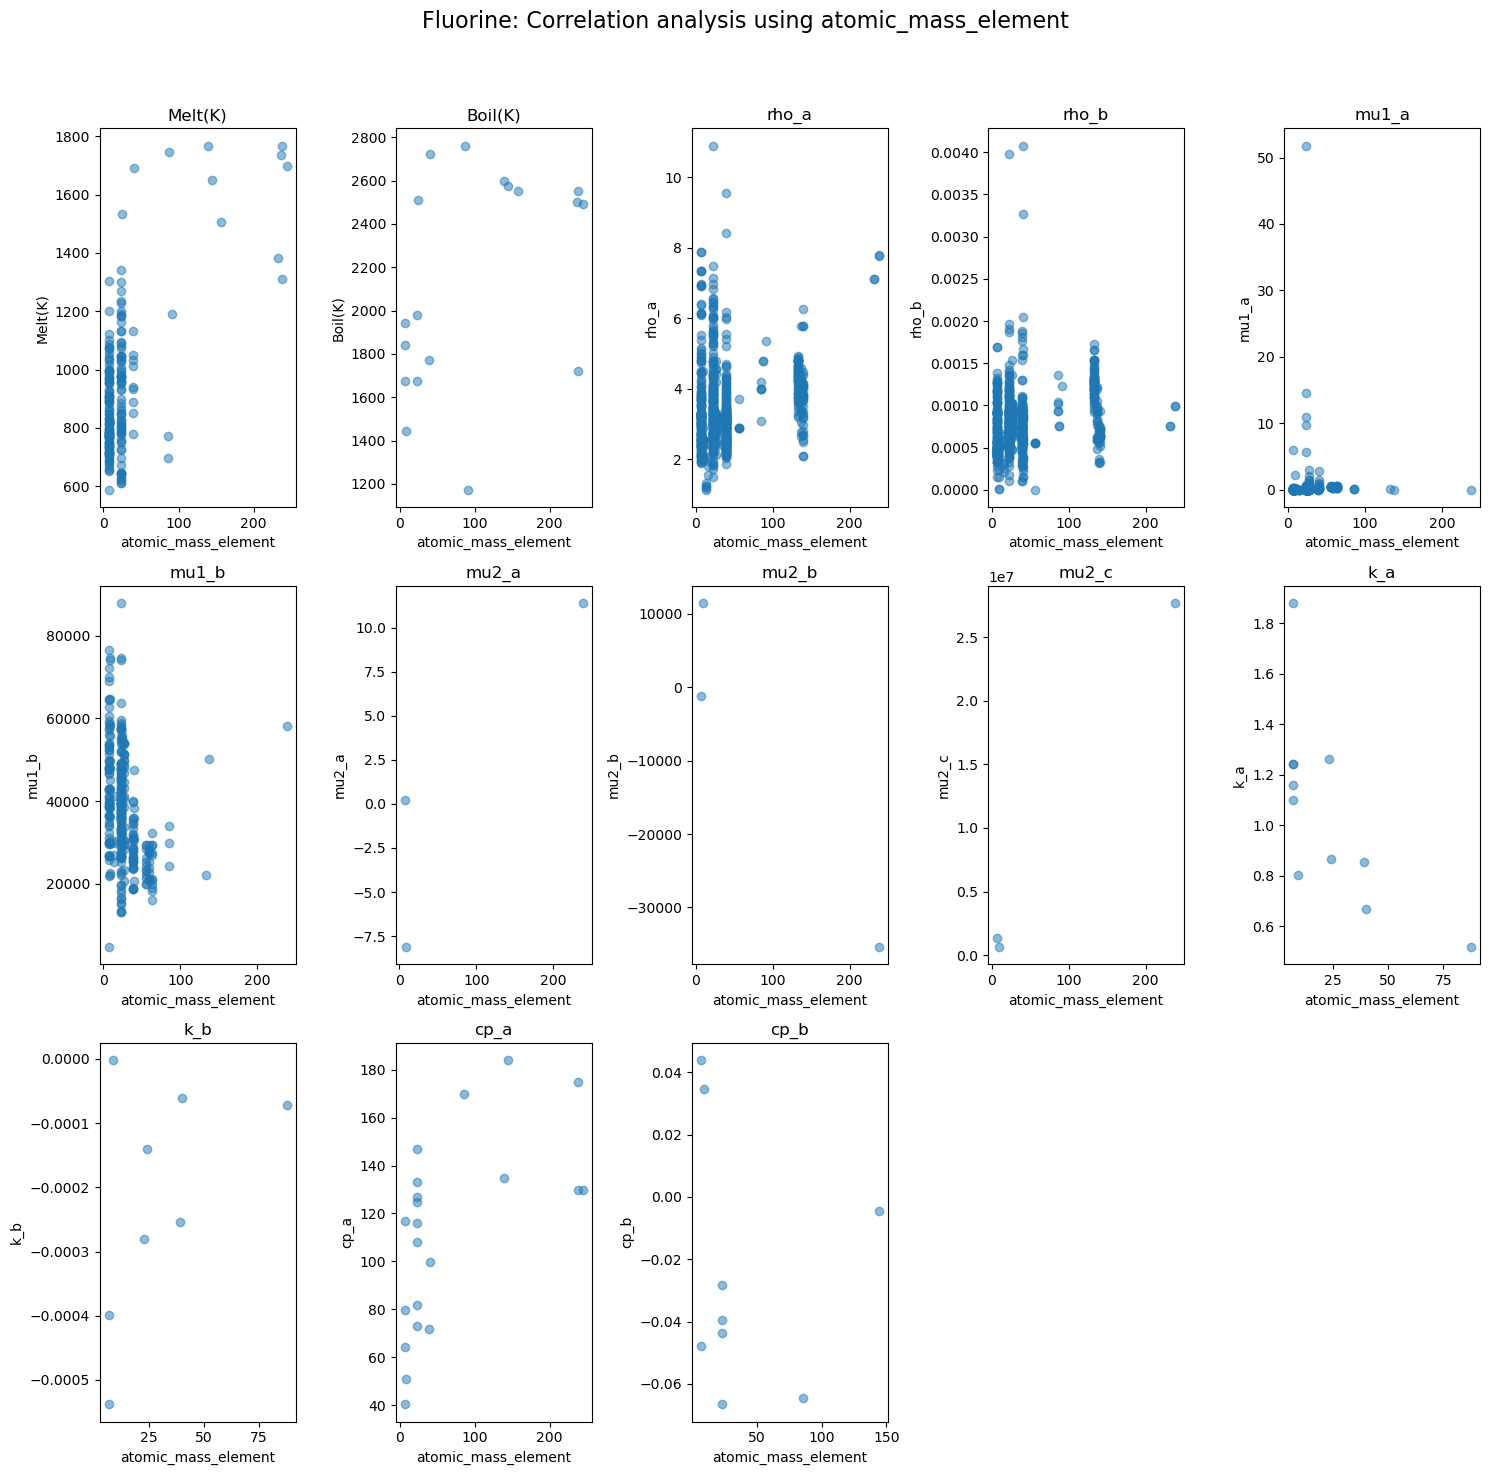

Correlation table:
         Correlation
Melt(K)     0.620871
Boil(K)     0.414541
rho_a       0.248885
rho_b       0.253921
mu1_a      -0.001531
mu1_b      -0.297410
mu2_a       0.901670
mu2_b      -0.963059
mu2_c       0.999524
k_a        -0.678389
k_b         0.477907
cp_a        0.580996
cp_b       -0.111864

================ electronegativity_element ================



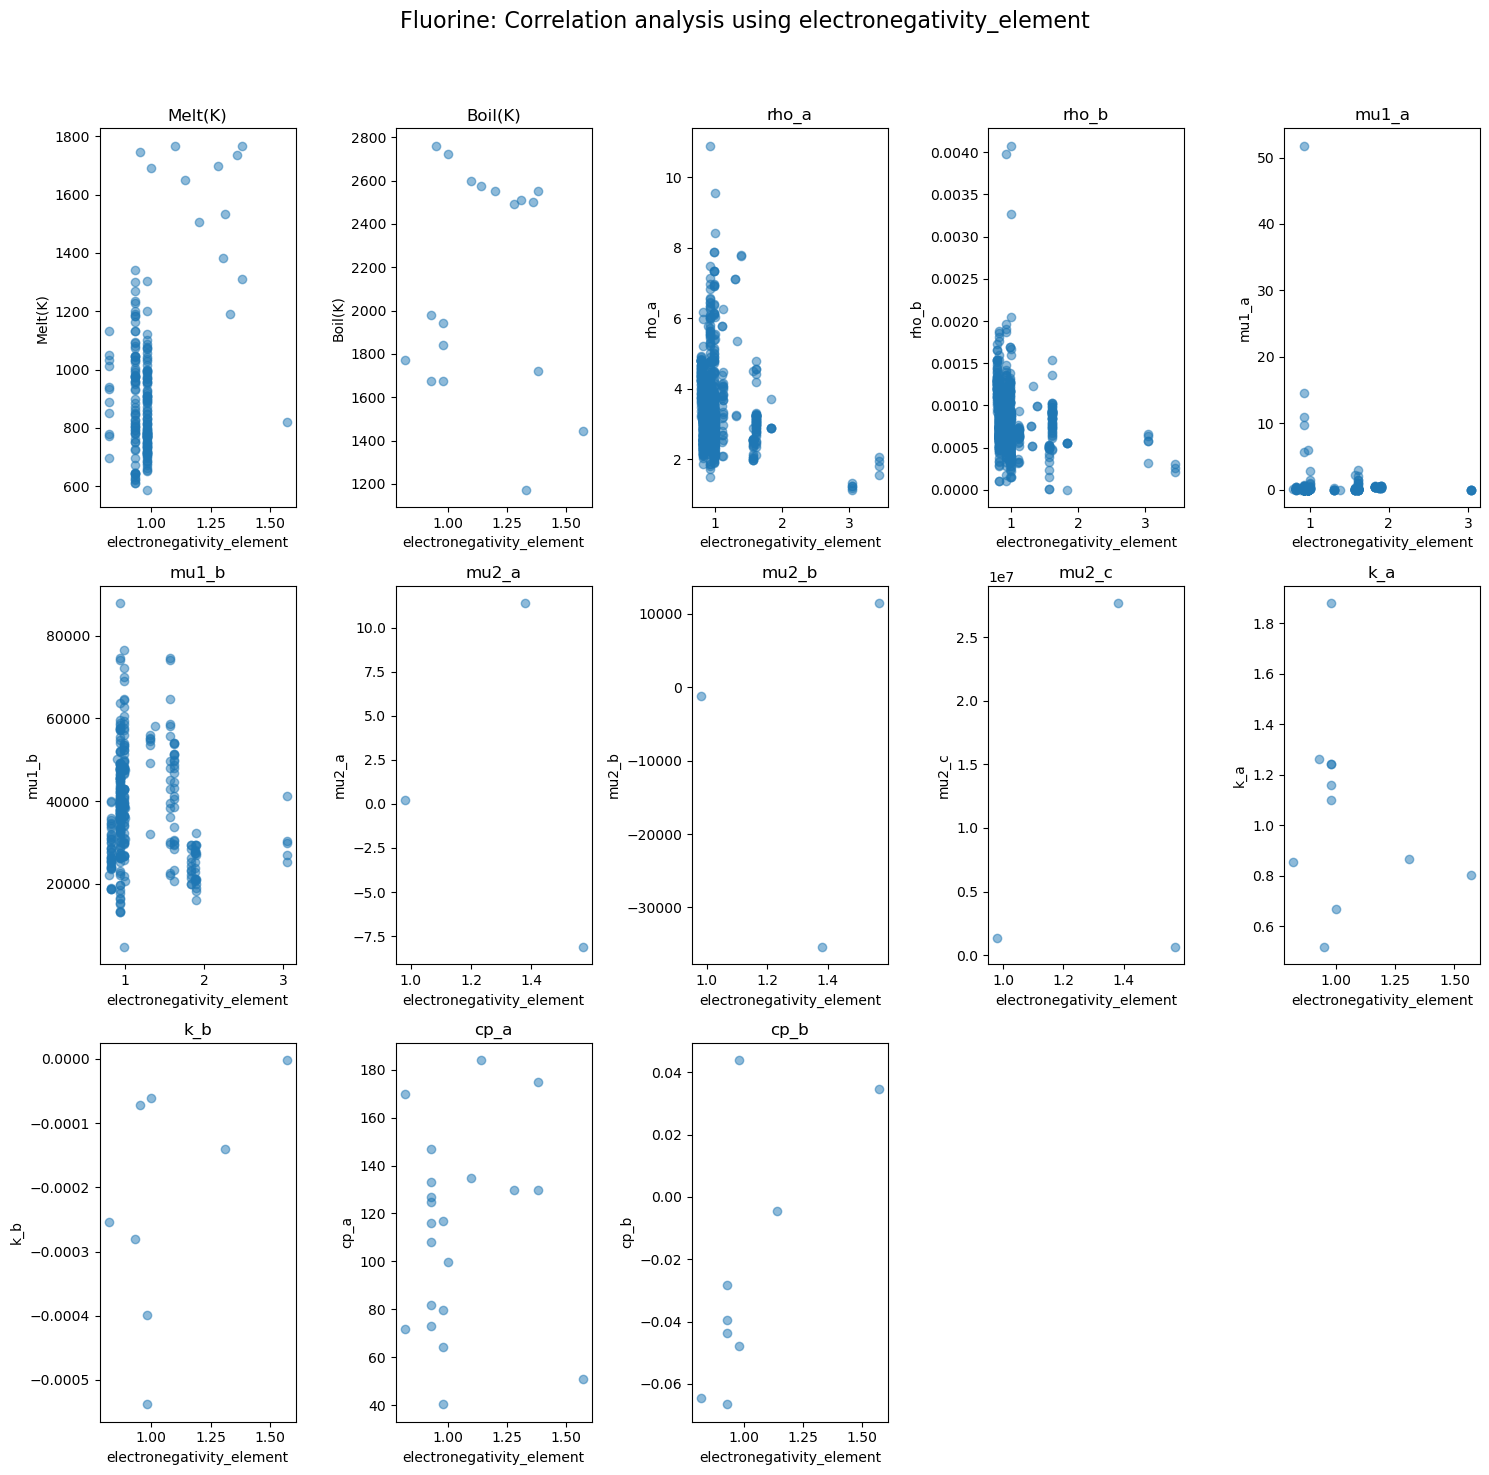

Correlation table:
         Correlation
Melt(K)     0.405067
Boil(K)    -0.046721
rho_a      -0.170670
rho_b      -0.168426
mu1_a      -0.023046
mu1_b      -0.147493
mu2_a      -0.234504
mu2_b       0.062145
mu2_c       0.178659
k_a        -0.230980
k_b         0.504272
cp_a        0.073639
cp_b        0.673903

================ atomic_radius_element[Angstrom] ================



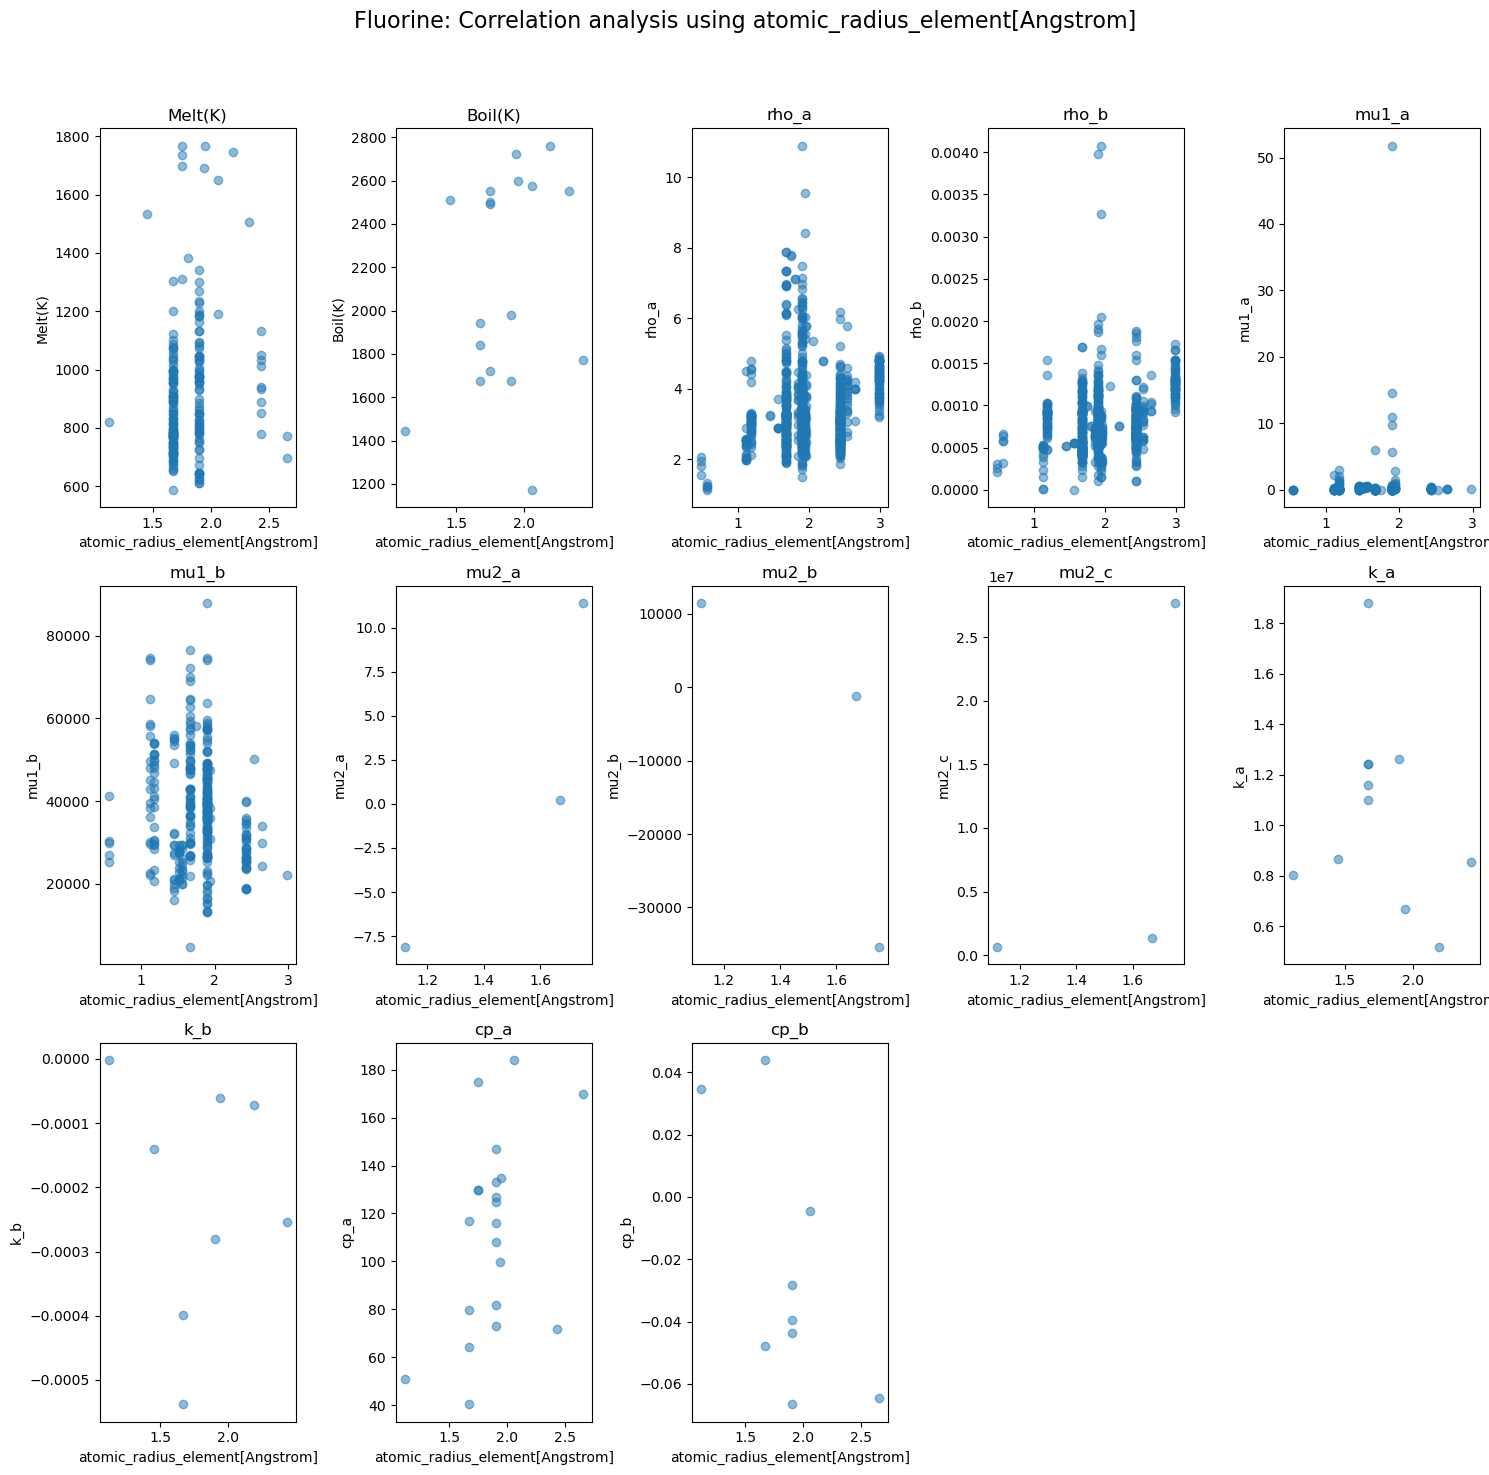

Correlation table:
         Correlation
Melt(K)     0.173488
Boil(K)     0.235149
rho_a       0.142156
rho_b       0.293558
mu1_a       0.015776
mu1_b      -0.167846
mu2_a       0.881899
mu2_b      -0.786642
mu2_c       0.615912
k_a        -0.234850
k_b        -0.109776
cp_a        0.427372
cp_b       -0.639480

================ ionic_radius_element[Angstrom] ================



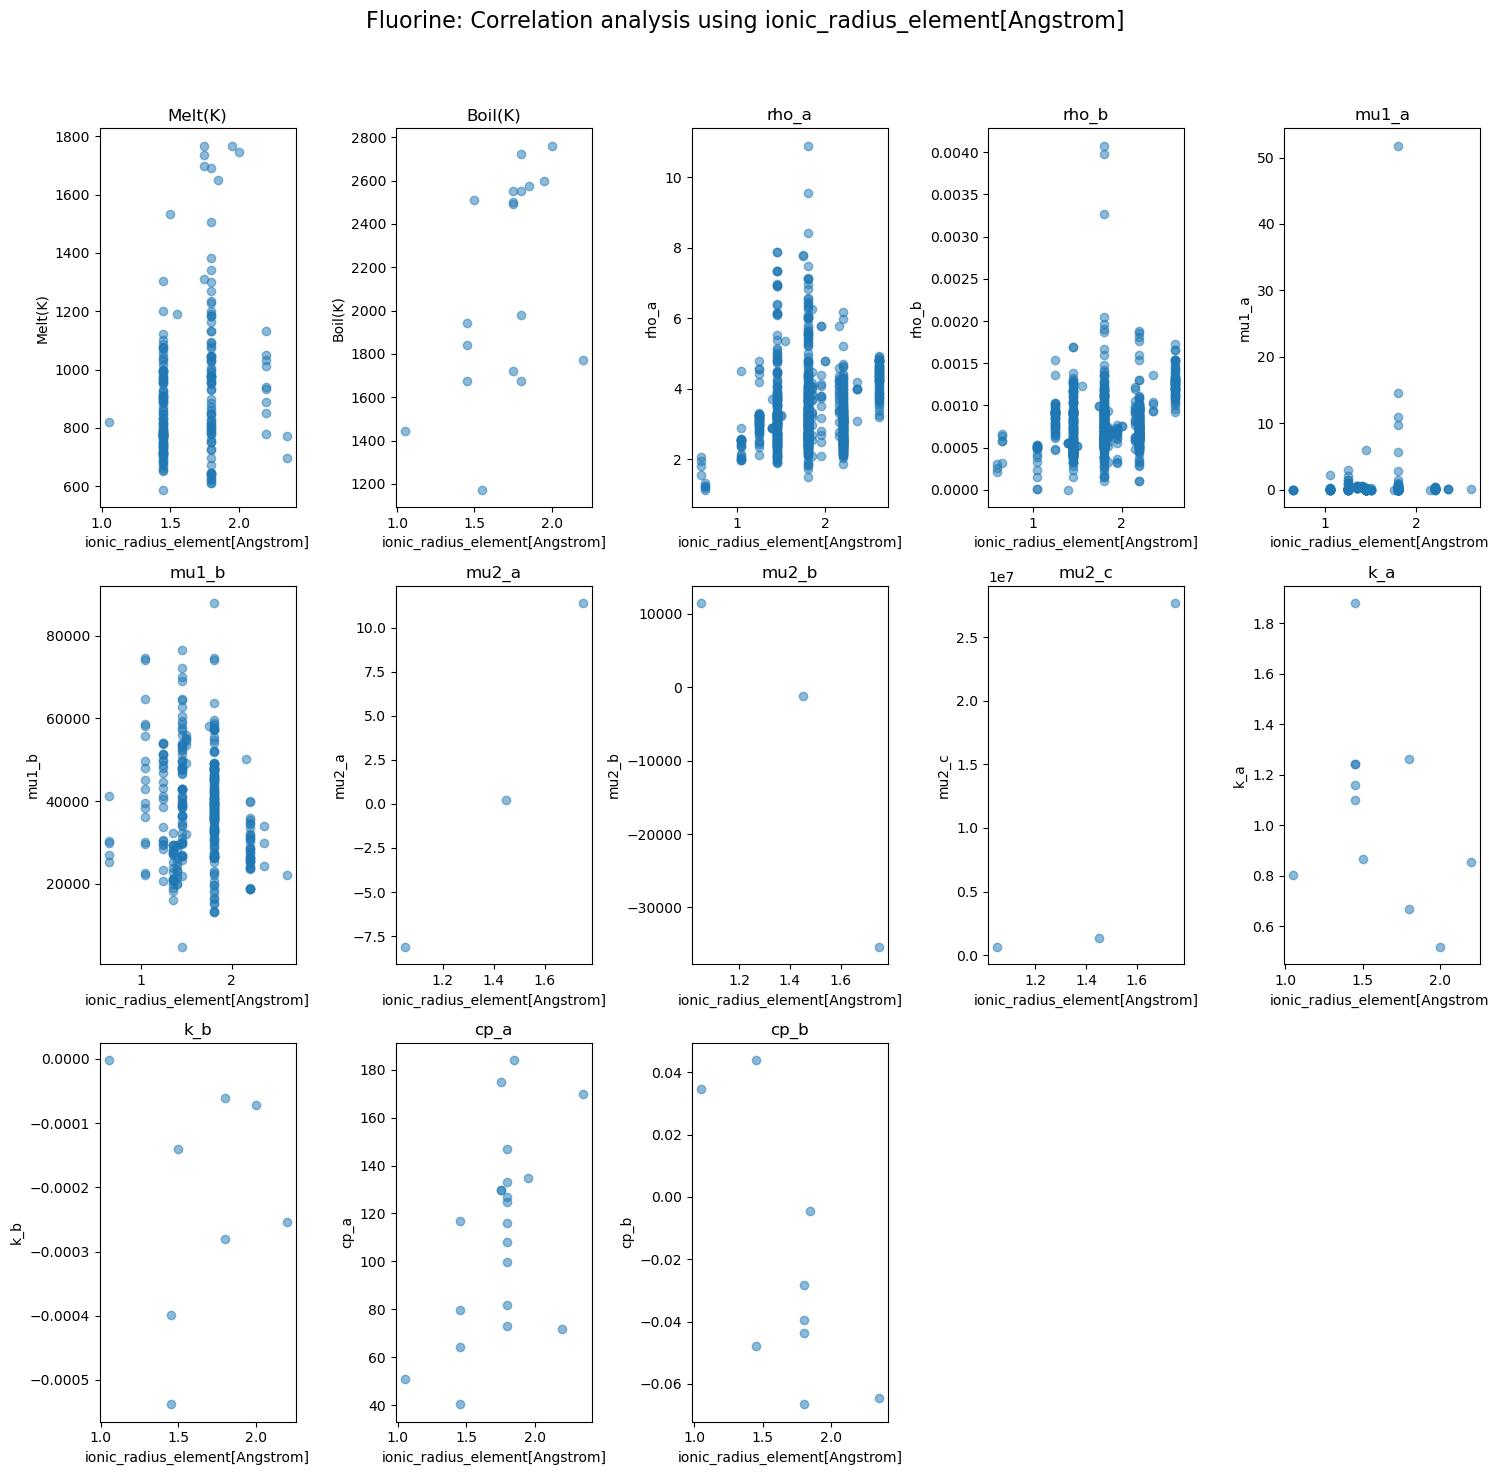

Correlation table:
         Correlation
Melt(K)     0.244025
Boil(K)     0.465236
rho_a       0.137154
rho_b       0.290049
mu1_a       0.026429
mu1_b      -0.160637
mu2_a       0.986170
mu2_b      -0.942411
mu2_c       0.834904
k_a        -0.348478
k_b         0.009761
cp_a        0.528431
cp_b       -0.694228

================ covalent_radius_element[Angstrom] ================



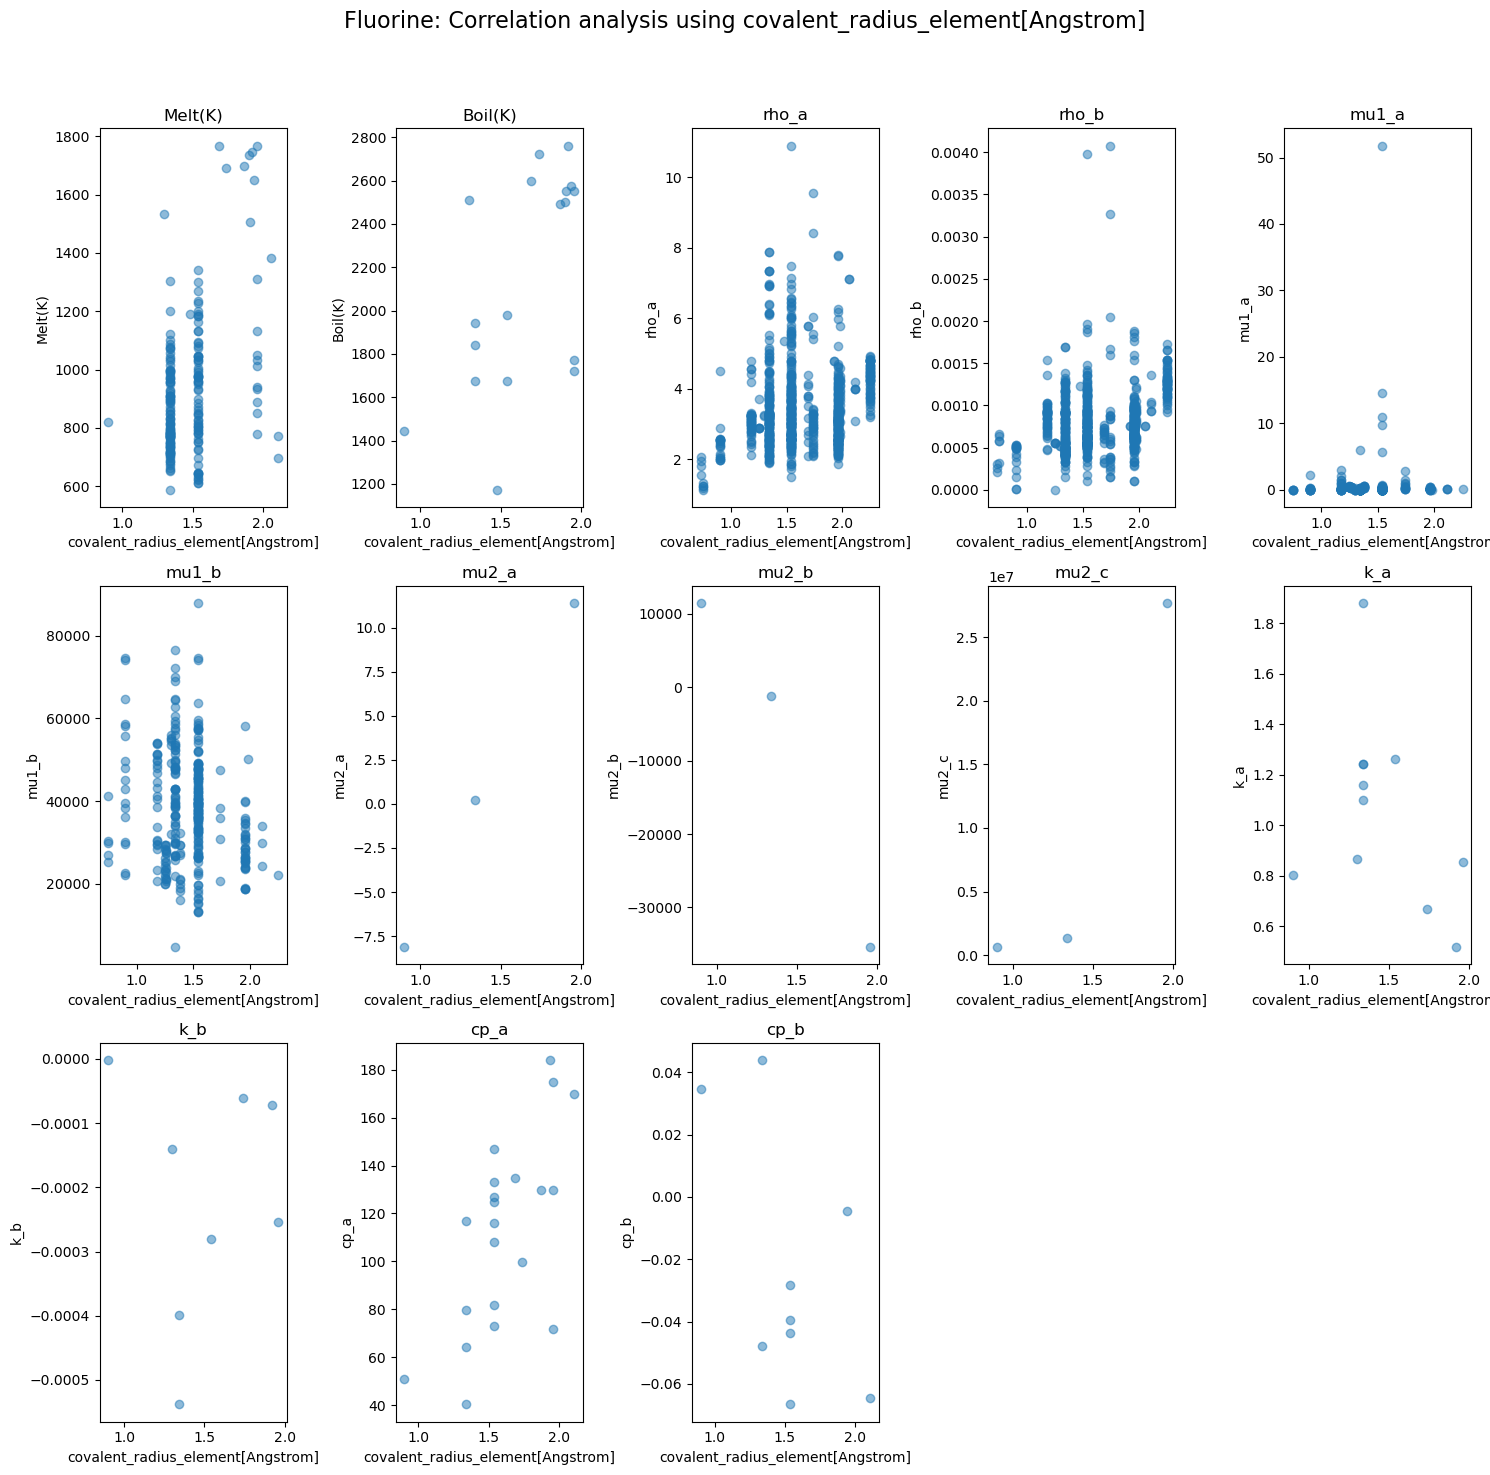

Correlation table:
         Correlation
Melt(K)     0.418981
Boil(K)     0.549475
rho_a       0.146332
rho_b       0.279771
mu1_a       0.016055
mu1_b      -0.200387
mu2_a       0.999909
mu2_b      -0.987066
mu2_c       0.919960
k_a        -0.372477
k_b         0.032690
cp_a        0.667407
cp_b       -0.545356

================ first_ionization_energy[kJ_per_mol] ================



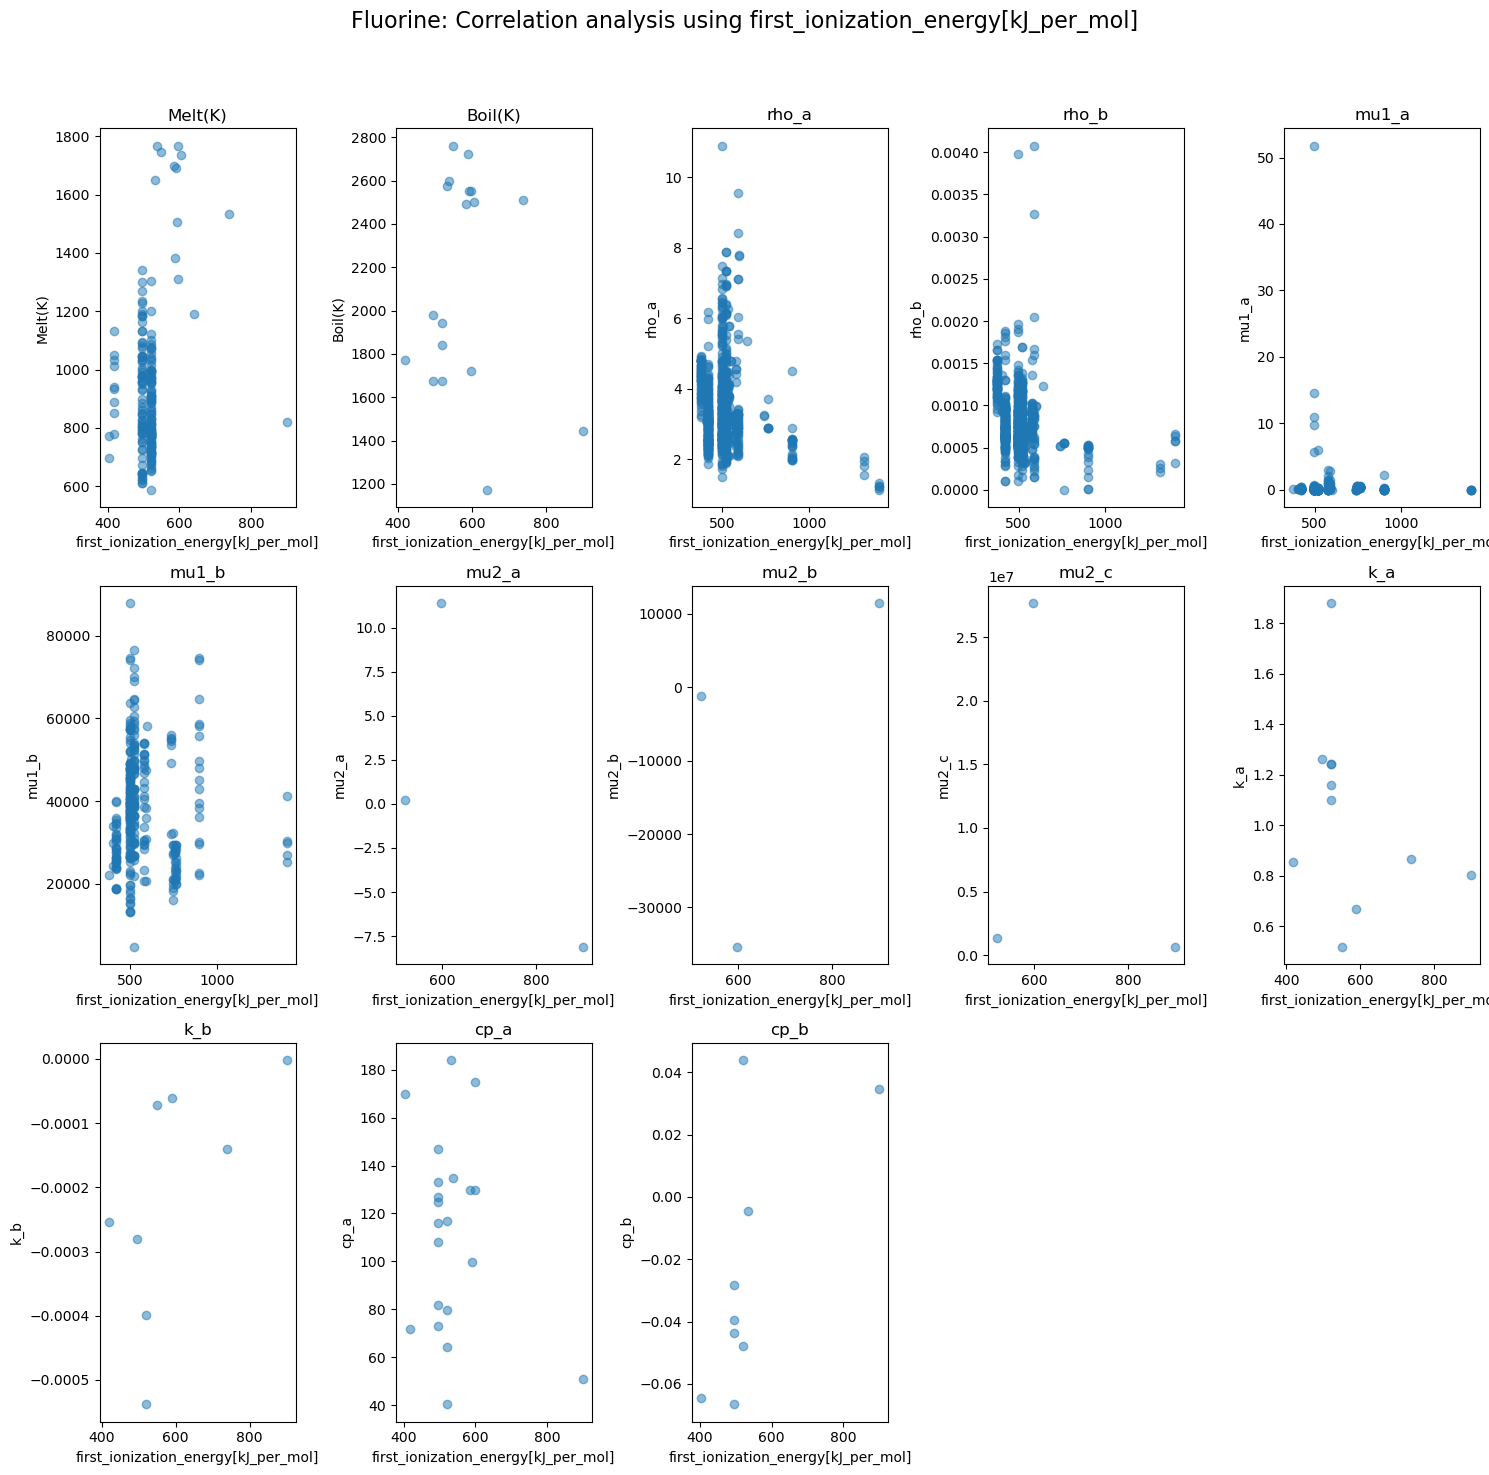

Correlation table:
         Correlation
Melt(K)     0.257752
Boil(K)    -0.101072
rho_a      -0.183989
rho_b      -0.245767
mu1_a      -0.025090
mu1_b      -0.041302
mu2_a      -0.695177
mu2_b       0.559798
mu2_c      -0.345089
k_a        -0.329788
k_b         0.596775
cp_a       -0.235275
cp_b        0.645535

================ COMBINED CORRELATION MATRIX ================

        polarizability_element[10-24Cm3] atomic_mass_element  \
                             Correlation         Correlation   
Melt(K)                         0.287538            0.620871   
Boil(K)                         0.333411            0.414541   
rho_a                           0.146587            0.248885   
rho_b                           0.272794            0.253921   
mu1_a                          -0.006085           -0.001531   
mu1_b                          -0.065233           -0.297410   
mu2_a                           0.999144            0.901670   
mu2_b                          -0.976786       

In [58]:



data_cols = [
    "polarizability_element[10-24Cm3]",
    "atomic_mass_element",
    "electronegativity_element",
    "atomic_radius_element[Angstrom]",
    "ionic_radius_element[Angstrom]",
    "covalent_radius_element[Angstrom]",
    "first_ionization_energy[kJ_per_mol]"
]

pred_cols = [
    "Melt(K)", "Boil(K)", "rho_a", "rho_b",
    "mu1_a", "mu1_b", "mu2_a", "mu2_b",
    "mu2_c", "k_a", "k_b", "cp_a", "cp_b"
]

tgt = data_clorine[pred_cols]

# =========================================================
# SAFE EVAL
# =========================================================
def safe_eval(x):
    if pd.isna(x):
        return np.nan
    try:
        value = ast.literal_eval(x)
        if not isinstance(value, dict):
            return np.nan

        cats = [k for k in value.keys() if k != "Cl"]
        if not cats:
            return np.nan

        return float(value[cats[0]])
    except Exception:
        return np.nan

# =========================================================
# CORRELATION ANALYSIS
# =========================================================
all_correlation_tables = {}

for atomic_col in data_cols:

    print(f"\n================ {atomic_col} ================\n")

    pred = data_clorine[atomic_col].apply(safe_eval)

    n_cols = 5
    n_rows = (len(tgt.columns) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    correlation_table = pd.DataFrame(
        index=tgt.columns,
        columns=["Correlation"],
        dtype=float
    )

    for i, target in enumerate(tgt.columns):

        mask = pred.notna() & tgt[target].notna()
        x = pred[mask]
        y = tgt[target][mask]

        if len(x) < 3:
            axes[i].set_title(f"{target}\n(insufficient data)")
            axes[i].axis("off")
            continue

        axes[i].scatter(x, y, alpha=0.5)
        axes[i].set_xlabel(atomic_col)
        axes[i].set_ylabel(target)
        axes[i].set_title(target)

        correlation_table.loc[target, "Correlation"] = x.corr(y)

    # remove unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    # -------- TITLE --------
    fig.suptitle(
        f"Fluorine: Correlation analysis using {atomic_col}",
        fontsize=16,
        y=0.98
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # -------- DISPLAY --------
    plt.show()

    # -------- SAVE --------
    safe_name = (
        atomic_col
        .replace("[", "")
        .replace("]", "")
        .replace("/", "_")
        .replace(" ", "_")
    )

    file_path = os.path.join(
        output_dir,
        f"Chlorine: correlation_{safe_name}.png"
    )

    fig.savefig(file_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print("Correlation table:")
    print(correlation_table)

    all_correlation_tables[atomic_col] = correlation_table

# =========================================================
# COMBINED CORRELATION MATRIX
# =========================================================
combined_correlation = pd.concat(all_correlation_tables, axis=1)

print("\n================ COMBINED CORRELATION MATRIX ================\n")
print(combined_correlation)


# First data models

In [ ]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None
    
selected_predictors = [0, 1, 2, 4, 5, 7]
pred = data[data_cols[selected_predictors]]
for col in pred.columns:
    pred[col] = pred[col].apply(safe_eval)

pred

/var/folders/yw/ymf0hshn7hd1dkyly48rpl100000gn/T/ipykernel_65810/3601344143.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred[col] = pred[col].apply(safe_eval)


,polarizability_element[10-24Cm3],atomic_mass_element,electronegativity_element,atomic_radius_element[Angstrom],ionic_radius_element[Angstrom],first_ionization_energy[kJ_per_mol]
0,8.34,26.982,1.61,1.18,1.25,577.5
1,5.60,9.012,1.57,1.12,1.05,899.5
3,25.00,40.078,1.00,1.94,1.80,589.8
5,26.00,157.250,1.20,2.33,1.80,593.4
7,43.40,39.098,0.82,2.43,2.20,418.8
...,...,...,...,...,...,...
4865,46.00,238.029,1.38,1.75,1.75,597.6
4866,46.00,238.029,1.38,1.75,1.75,597.6
4869,22.00,88.906,1.22,2.12,1.85,600.0
4872,7.08,65.380,1.65,1.42,1.35,906.4


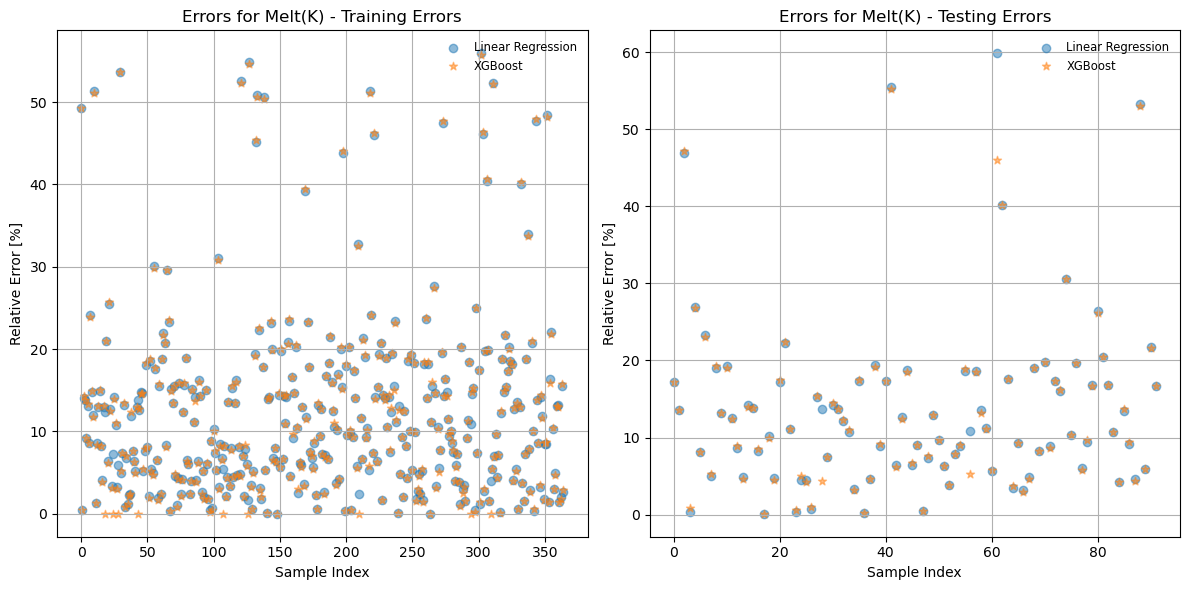

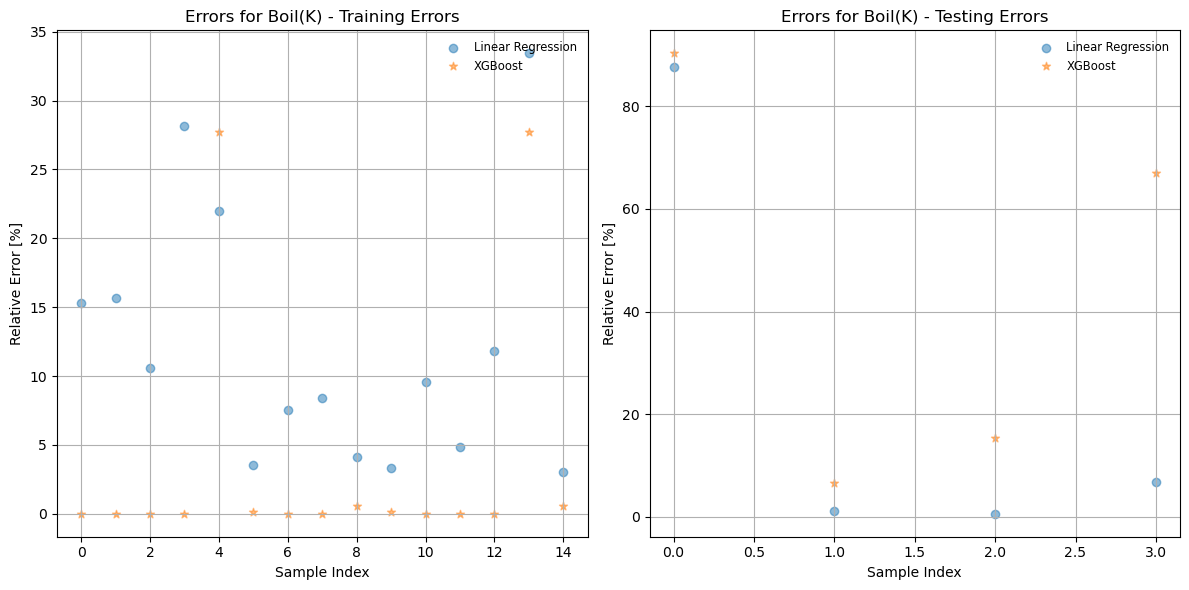

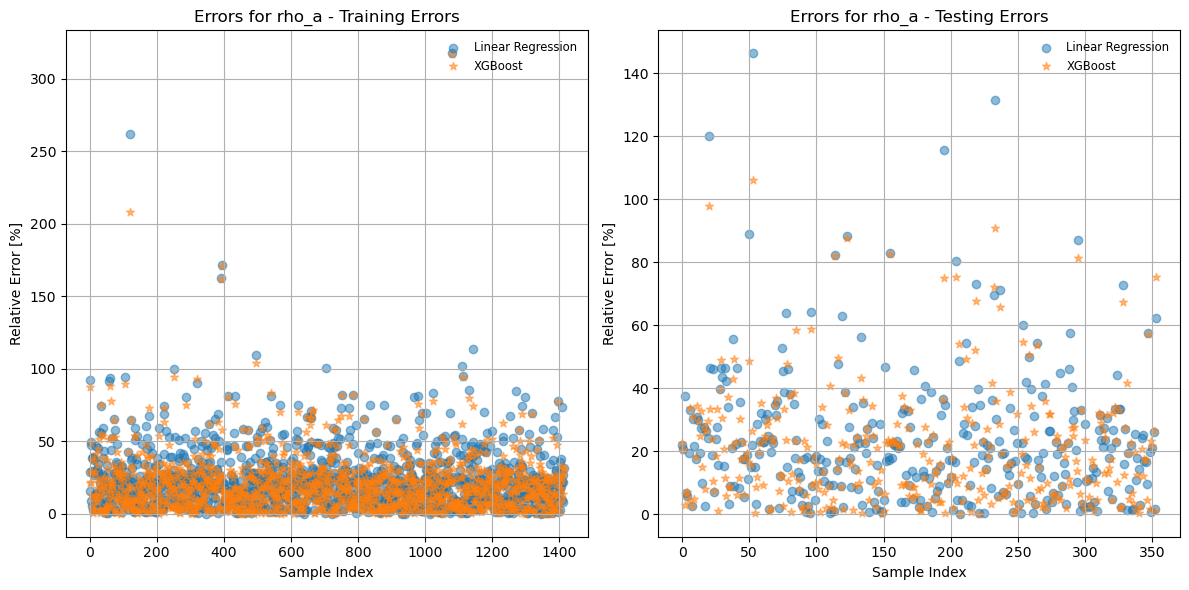

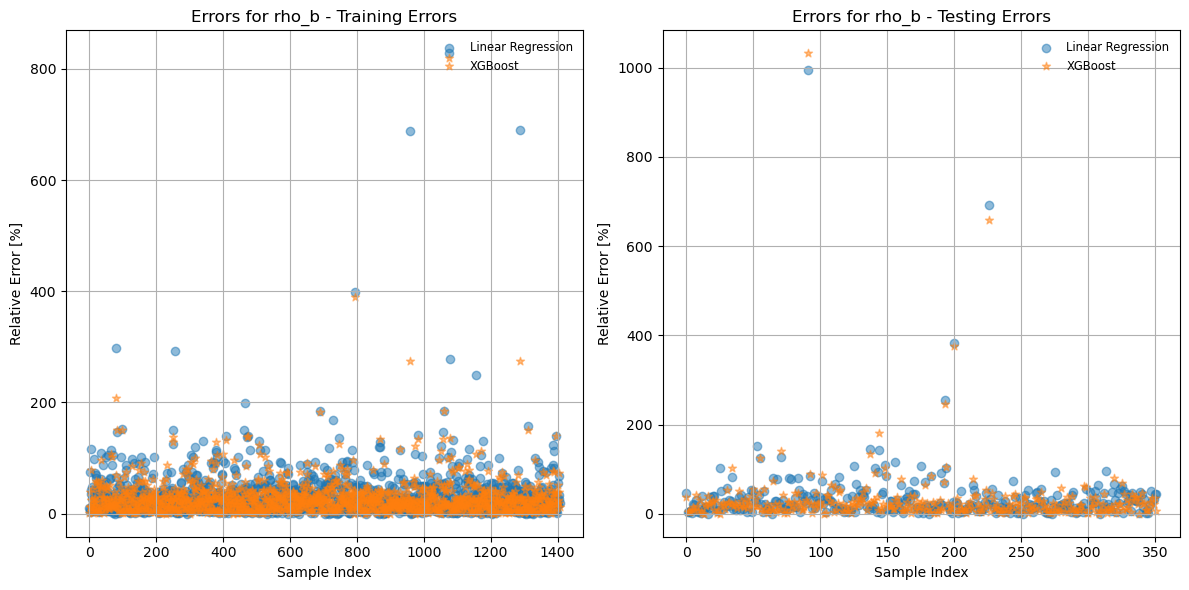

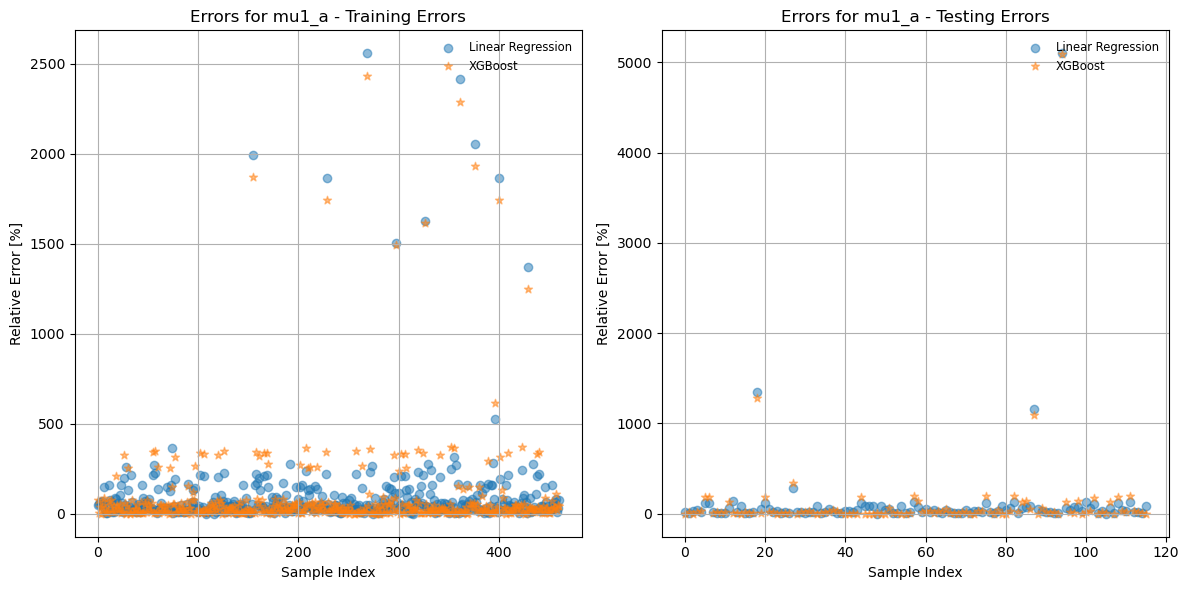

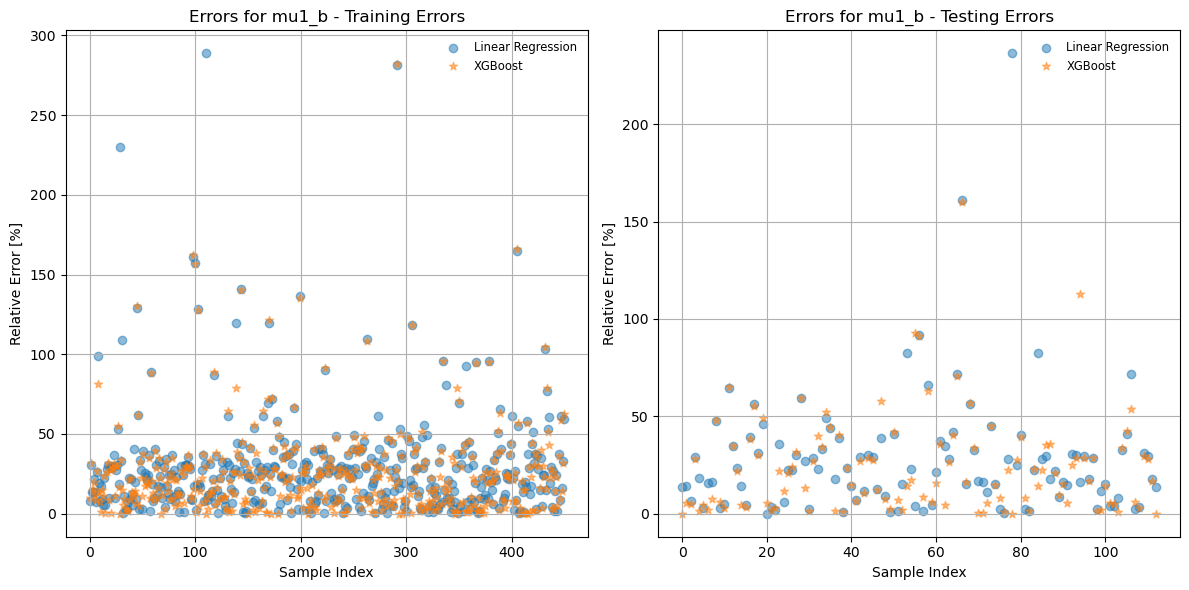

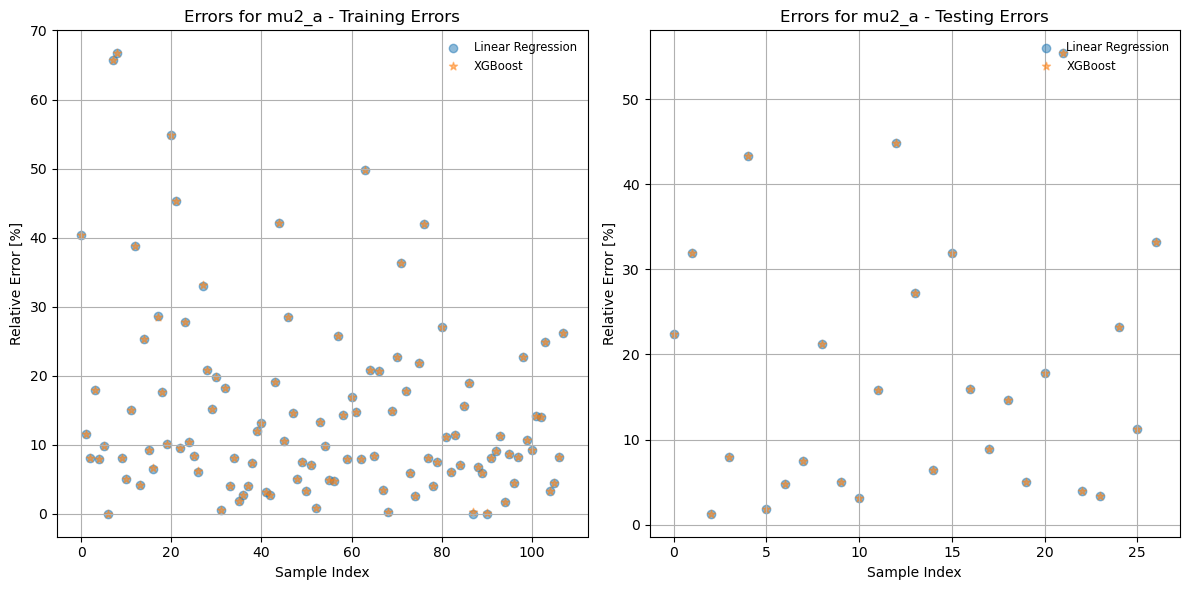

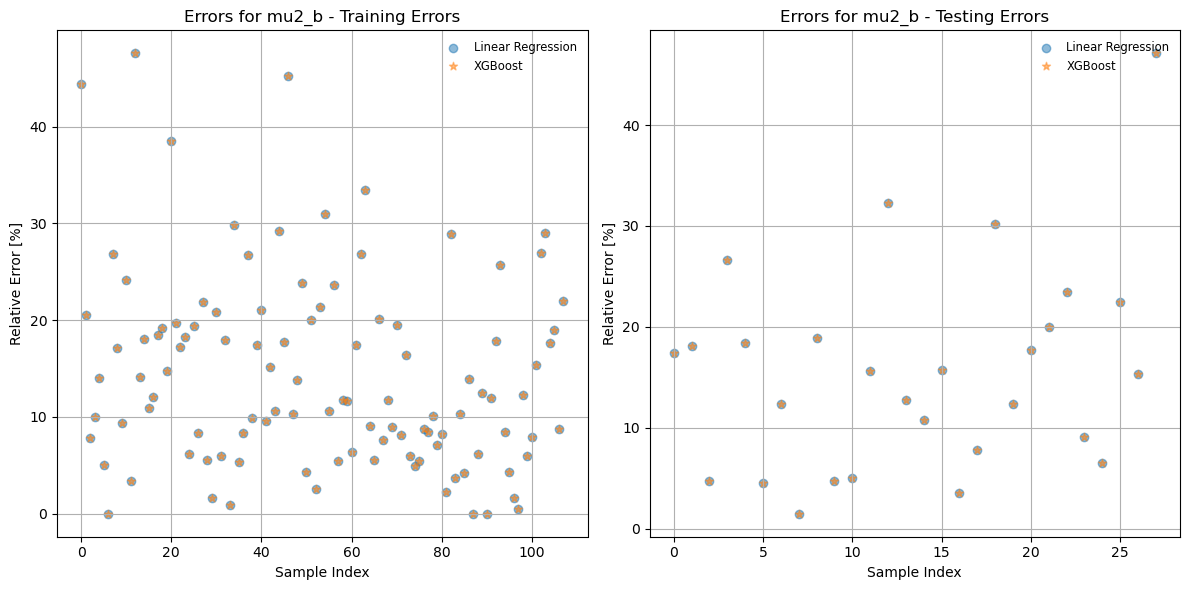

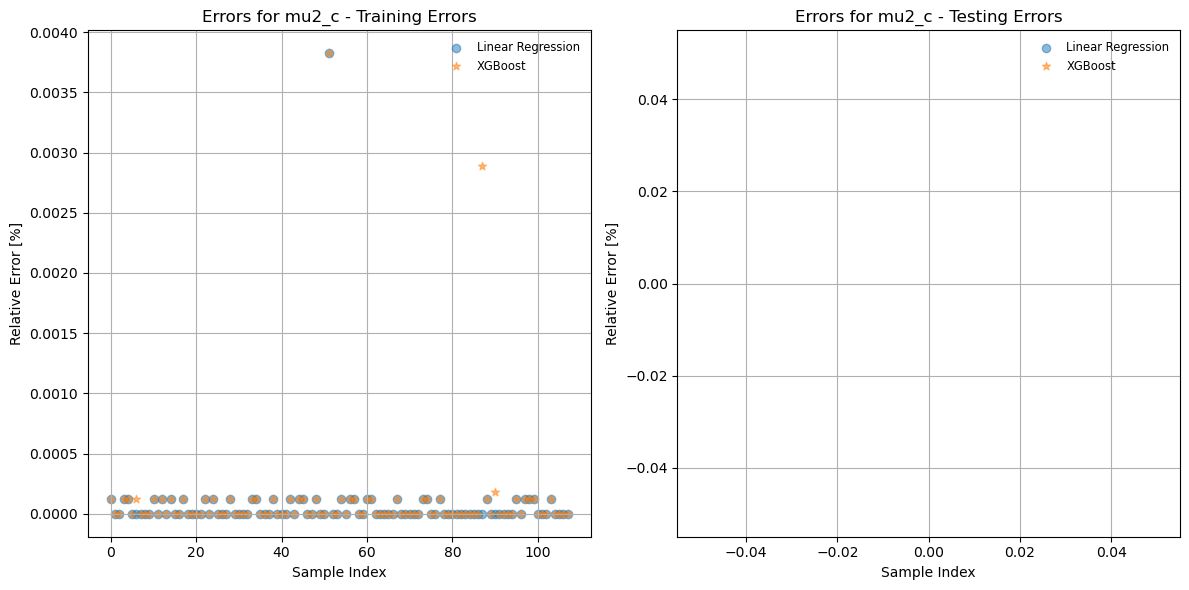

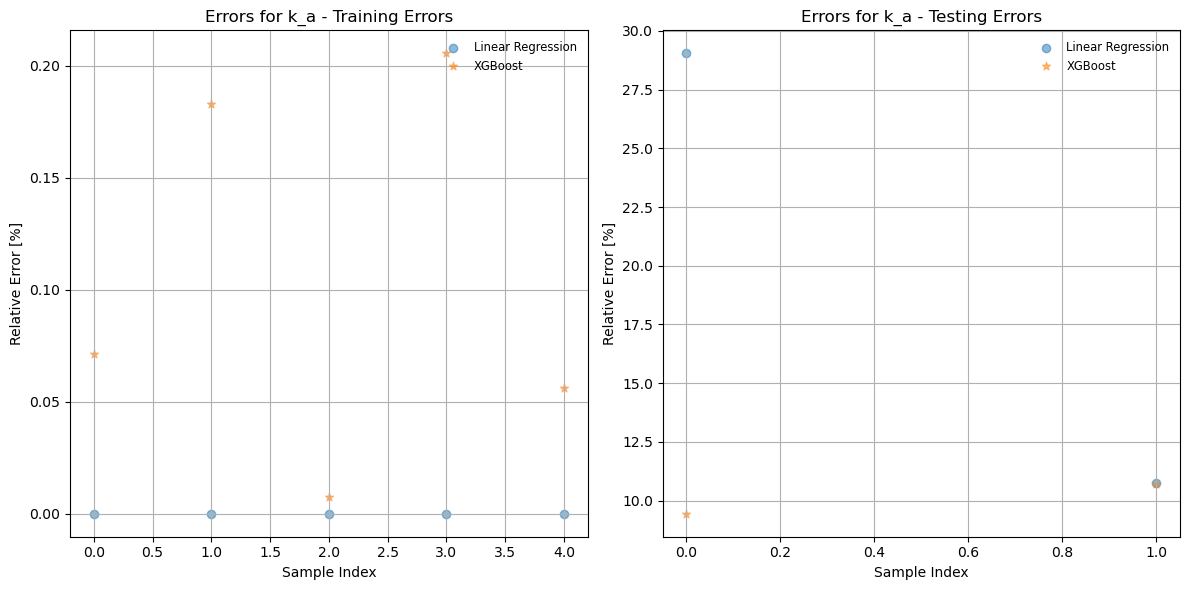

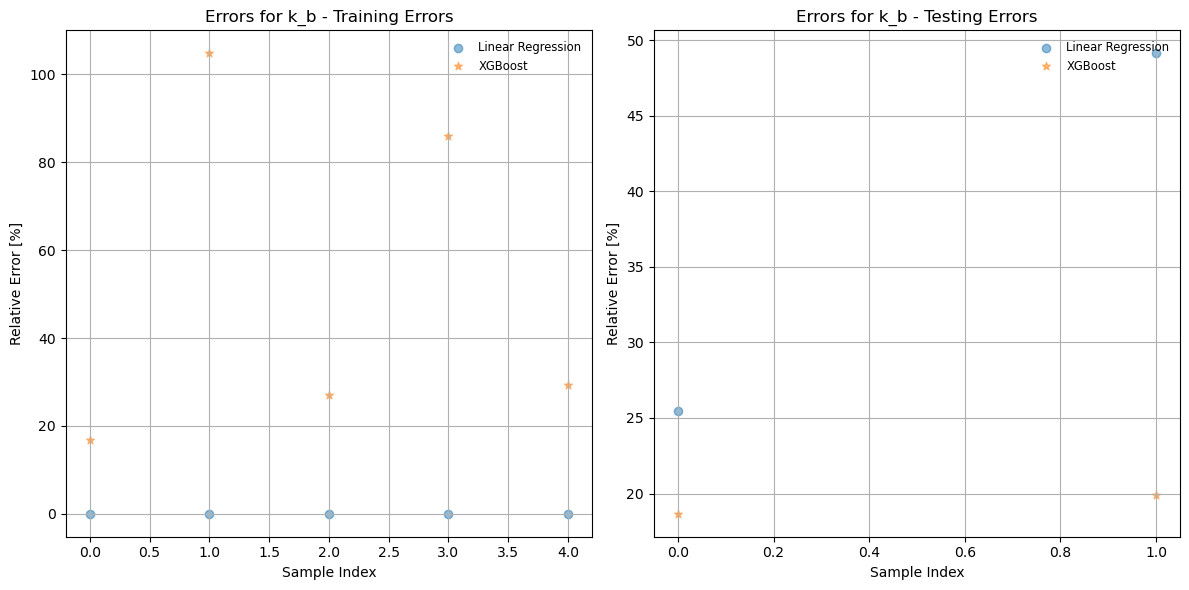

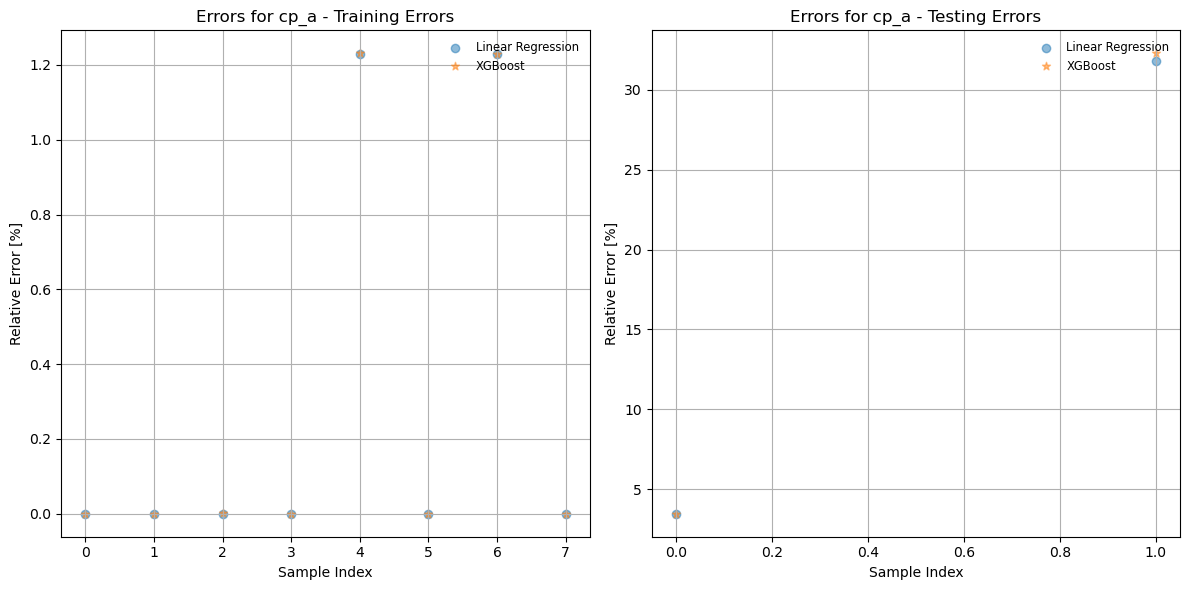

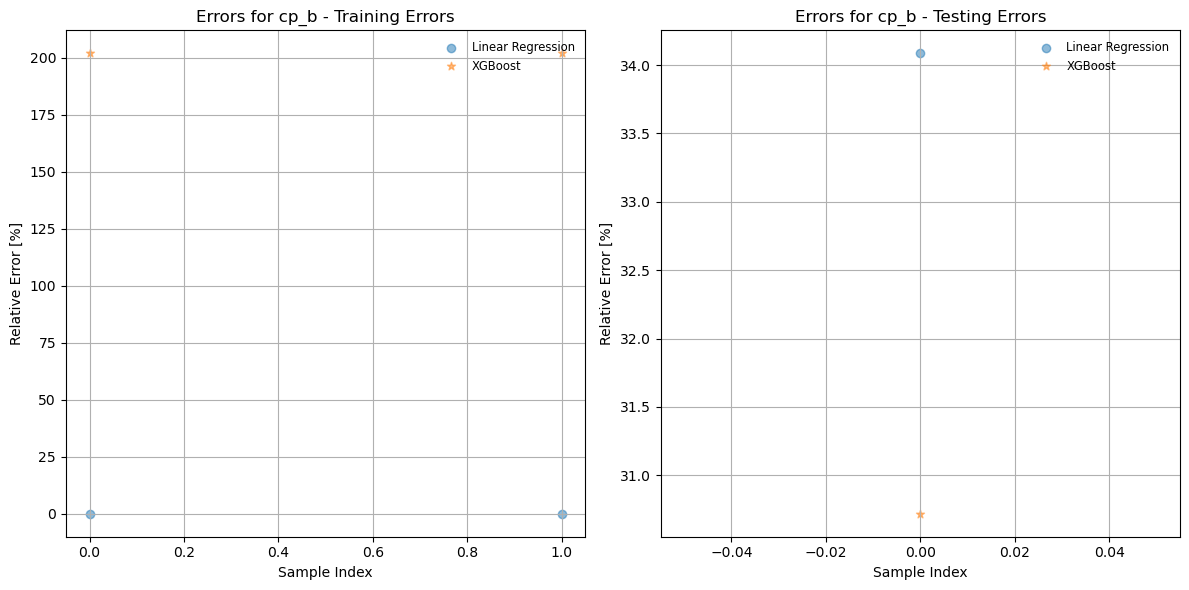

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Function to clean feature names
def clean_feature_names(columns):
    cleaned_columns = []
    for col in columns:
        col_str = str(col)  # Ensure it's a string
        col_str = col_str.replace('[', '').replace(']', '').replace('<', '').replace('>', '').replace(' ', '_')
        cleaned_columns.append(col_str)
    return cleaned_columns

# Assuming pred and tgt are your datasetsss
X = pred.copy()
X.columns = clean_feature_names(X.columns)

# Define available methods
# available_methods = ['Linear Regression', 
#                      'Polynomial Regression (degree 2)', 
#                      'Polynomial Regression (degree 3)', 
#                      'Polynomial Regression (degree 4)',
#                      'Decision Tree', 
#                      'Random Forest', 
#                      'XGBoost', 
#                      'SVR']

available_methods = ['Linear Regression', 'XGBoost']

# Select methods to visualize
selected_methods = available_methods  # You can modify this to select specific methods

results = {method: {} for method in selected_methods}

# Iterate over each column in tgt to predict one at a time
for column in tgt.columns:
    y = tgt[column].dropna()
    X_filtered = X.loc[y.index]

    # Split the data
    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y, test_size=0.2, random_state=42)

    # Store training errors for each method
    for method in selected_methods:
        results[method][column] = {}

    # 1. Linear Regression
    lin_reg = LinearRegression()
    lin_reg.fit(X_train, y_train)
    y_pred_lin_train = lin_reg.predict(X_train)
    y_pred_lin_test = lin_reg.predict(X_test)
    results['Linear Regression'][column] = (y_train, y_pred_lin_train, y_test, y_pred_lin_test)

    # Polynomial Regression
    for degree in [2, 3, 4]:
        if f'Polynomial Regression (degree {degree})' in selected_methods:
            poly_features = PolynomialFeatures(degree=degree)
            X_poly_train = poly_features.fit_transform(X_train)
            X_poly_test = poly_features.transform(X_test)
            lin_reg.fit(X_poly_train, y_train)
            y_pred_poly_train = lin_reg.predict(X_poly_train)
            y_pred_poly_test = lin_reg.predict(X_poly_test)
            results[f'Polynomial Regression (degree {degree})'][column] = (y_train, y_pred_poly_train, y_test, y_pred_poly_test)

    # 2. Decision Tree
    if 'Decision Tree' in selected_methods:
        tree_reg = DecisionTreeRegressor()
        tree_reg.fit(X_train, y_train)
        y_pred_tree_train = tree_reg.predict(X_train)
        y_pred_tree_test = tree_reg.predict(X_test)
        results['Decision Tree'][column] = (y_train, y_pred_tree_train, y_test, y_pred_tree_test)

    # 3. Random Forest
    if 'Random Forest' in selected_methods:
        forest_reg = RandomForestRegressor(n_estimators=100)
        forest_reg.fit(X_train, y_train)
        y_pred_forest_train = forest_reg.predict(X_train)
        y_pred_forest_test = forest_reg.predict(X_test)
        results['Random Forest'][column] = (y_train, y_pred_forest_train, y_test, y_pred_forest_test)

    # 4. XGBoost
    if 'XGBoost' in selected_methods:
        xgb_reg = xgb.XGBRegressor()
        xgb_reg.fit(X_train, y_train)
        y_pred_xgb_train = xgb_reg.predict(X_train)
        y_pred_xgb_test = xgb_reg.predict(X_test)
        results['XGBoost'][column] = (y_train, y_pred_xgb_train, y_test, y_pred_xgb_test)

    # 5. Support Vector Regression
    if 'SVR' in selected_methods:
        svr_reg = SVR()
        svr_reg.fit(X_train, y_train)
        y_pred_svr_train = svr_reg.predict(X_train)
        y_pred_svr_test = svr_reg.predict(X_test)
        results['SVR'][column] = (y_train, y_pred_svr_train, y_test, y_pred_svr_test)

# Function to create side-by-side error plots for training and testing
def error_plot(y_true_train, y_pred_train, y_true_test, y_pred_test, title):
    plt.figure(figsize=(12, 6))

    # Define marker styles for each method
    marker_styles = {
        'Linear Regression': 'o',
        'Polynomial Regression (degree 2)': 's',
        'Polynomial Regression (degree 3)': 'D',
        'Polynomial Regression (degree 4)': '^',
        'Decision Tree': 'x',
        'Random Forest': 'P',
        'XGBoost': '*',
        'SVR': 'v'
    }

    # Plot training errors
    plt.subplot(1, 2, 1)
    for method in selected_methods:
        if method in results and column in results[method]:
            y_train, y_pred_train, y_test, y_pred_test = results[method][column]
            plt.scatter(np.arange(len(y_true_train)), np.abs(y_true_train - y_pred_train)/abs(np.mean(y_true_train))*100, 
                        alpha=0.5, marker=marker_styles[method], label=method)
    plt.xlabel('Sample Index')
    plt.ylabel('Relative Error [%]')
    plt.title(title + ' - Training Errors')
    plt.grid(True)
    plt.legend(loc='upper right', fontsize='small', frameon=False)

    # Plot testing errors
    plt.subplot(1, 2, 2)
    for method in selected_methods:
        if method in results and column in results[method]:
            y_train, y_pred_train, y_test, y_pred_test = results[method][column]
            plt.scatter(np.arange(len(y_true_test)), np.abs(y_true_test - y_pred_test)/abs(np.mean(y_true_test))*100, 
                        alpha=0.5, marker=marker_styles[method], label=method)
    plt.xlabel('Sample Index')
    plt.ylabel('Relative Error [%]')
    plt.title(title + ' - Testing Errors')
    plt.grid(True)
    plt.legend(loc='upper right', fontsize='small', frameon=False)

    plt.tight_layout()
    plt.show()

# Generate error plots for selected methods and each column
for column in tgt.columns:
    # Call the error plot function for each target column
    # for method in selected_methods:
        # if method in results and column in results[method]:
    y_train, y_pred_train, y_test, y_pred_test = results[method][column]
    error_plot(y_train, y_pred_train, y_test, y_pred_test, f'Errors for {column}')

In [ ]:
y_train

15   -0.007531
61    0.008490
Name: cp_b, dtype: float64

Error evaluating {'Gd': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x1437e1c10>
Error evaluating {'Nd': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x143900c70>
Error evaluating {'Np': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x143900520>
Error evaluating {'Pu': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x1439009d0>
Error evaluating {'Th': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x1439004c0>
Error evaluating {'U': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x143900e20>
Error evaluating {'U': nan, 'Cl': 0.99}: malformed node or string: <ast.Name object at 0x1439007f0>
Error evaluating {'K': 1.96, 'Cl': 0.99, 'U': nan}: malformed node or string: <ast.Name object at 0x146048b80>
Error evaluating {'K': 1.96, 'Cl': 0.99, 'U': nan}: malformed node or string: <ast.Name object at 0x146048ee0>
Error evaluating {'K': 1.96, 'Cl': 0.99, 'U': nan}: malformed node or str

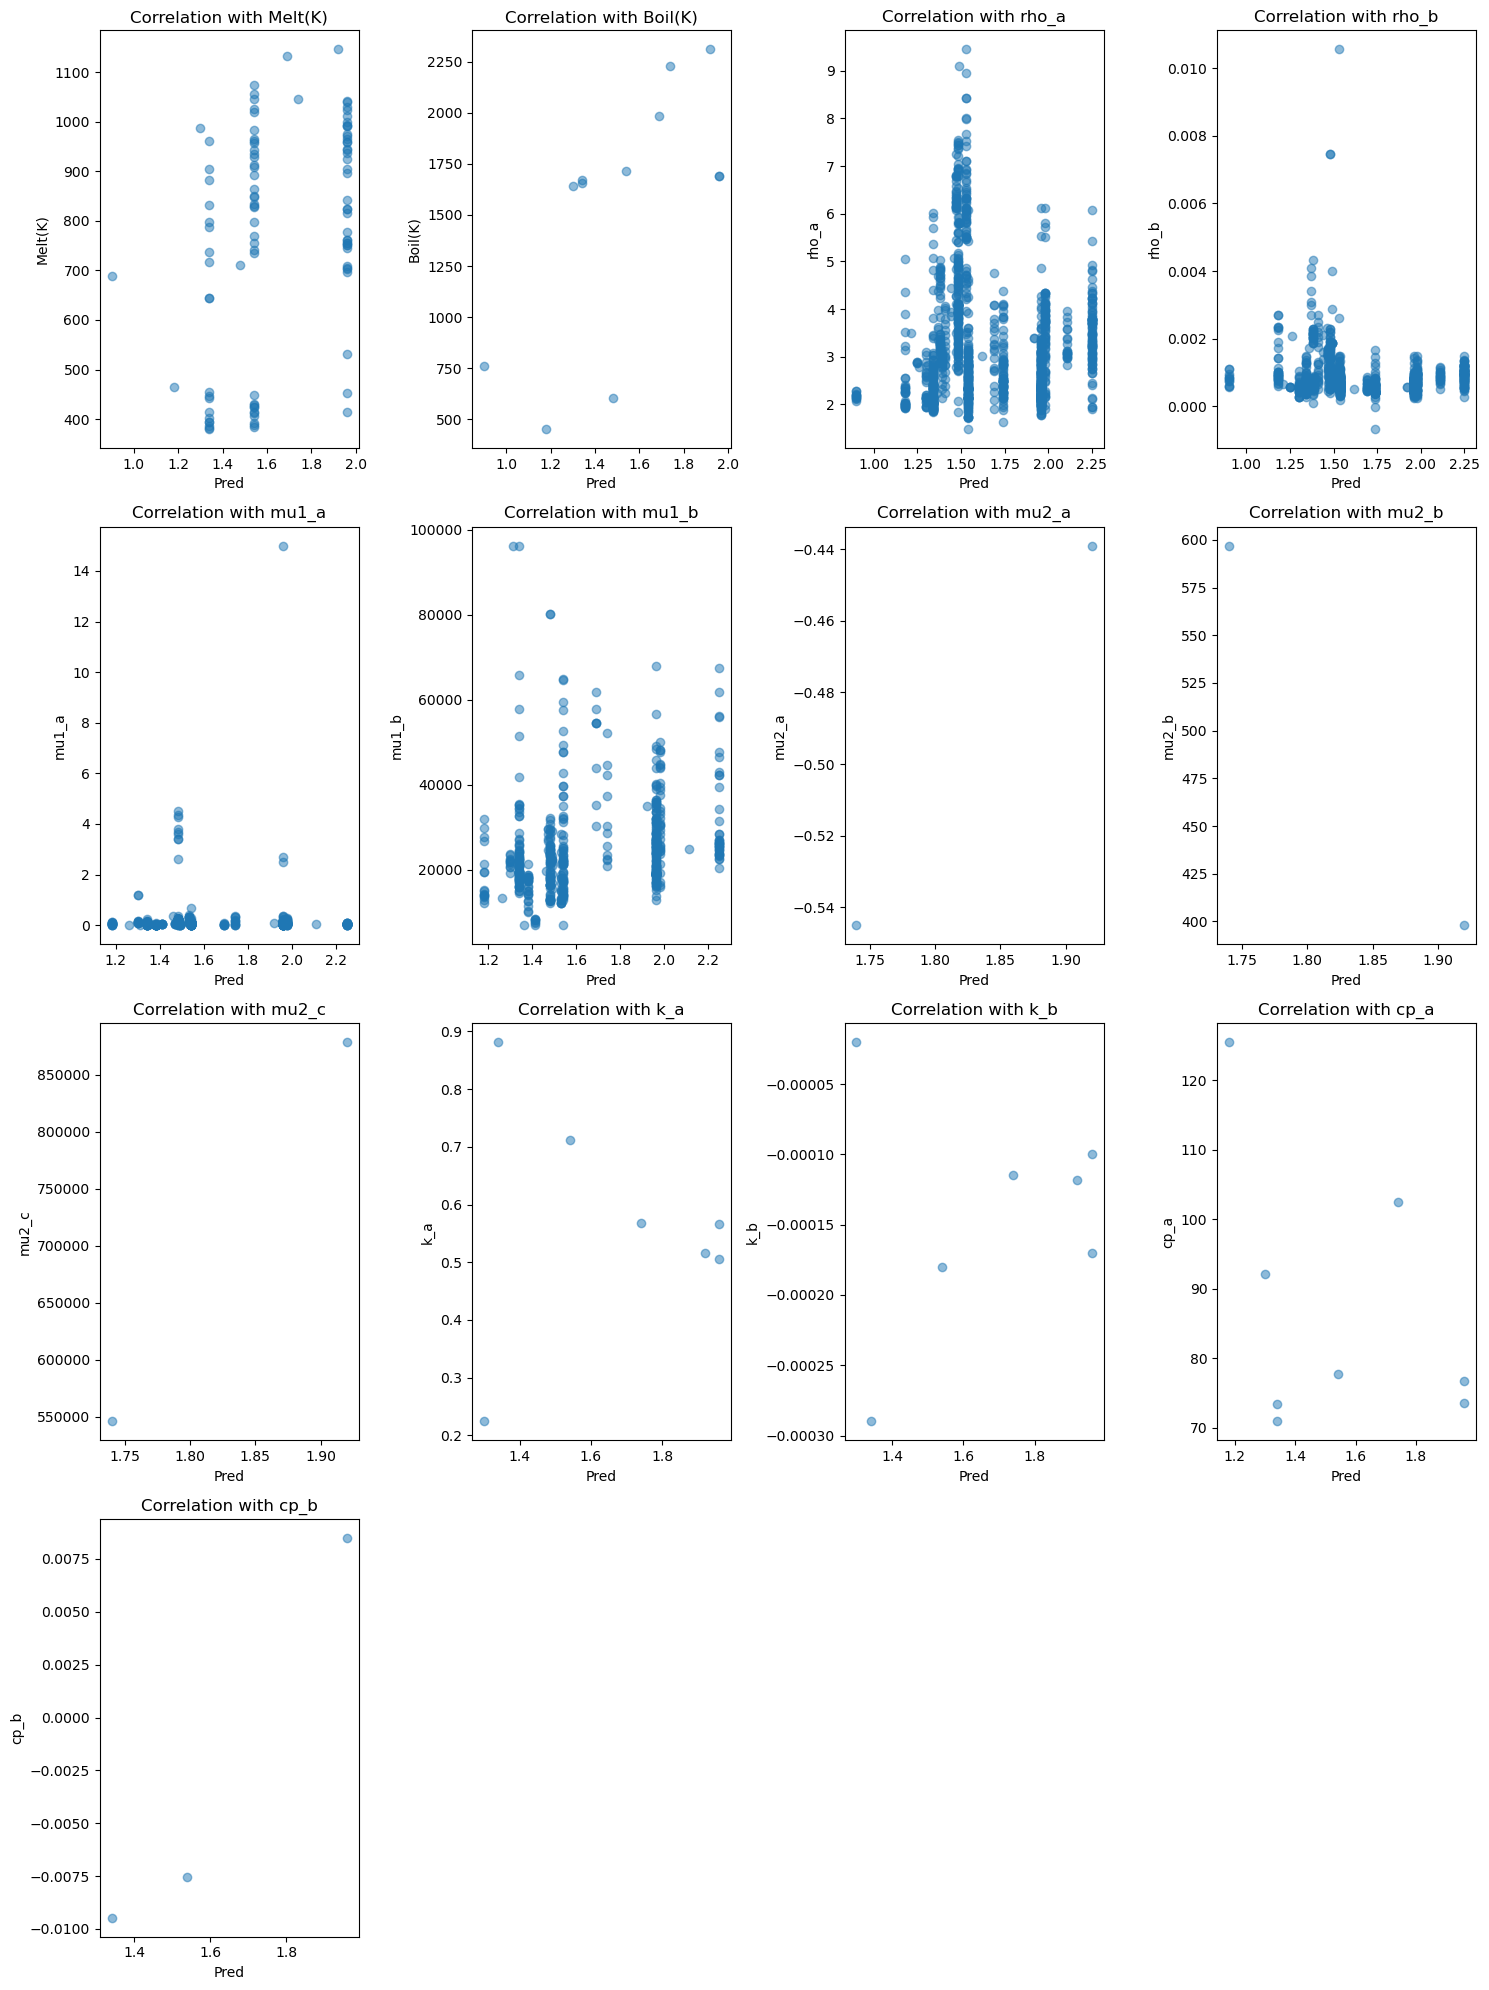

Correlation Table:
        Correlation
Melt(K)    0.382525
Boil(K)    0.667653
rho_a     -0.099922
rho_b     -0.165922
mu1_a     -0.014598
mu1_b      0.253606
mu2_a           1.0
mu2_b          -1.0
mu2_c           1.0
k_a       -0.077088
k_b        0.142214
cp_a       -0.38814
cp_b        0.97526


In [ ]:
def safe_eval(x):
    try:
        value = ast.literal_eval(x)
        keys = value.keys()
        cats = [key for key in keys if key != 'Cl']
        return value[cats[0]]
    except Exception as e:
        print(f"Error evaluating {x}: {e}")
        return None

# Assuming 'data' is your DataFrame and 'data_cols' and 'pred_cols' are lists containing the relevant columns.
pred = data[data_cols[6]].apply(safe_eval)
tgt = data[pred_cols]

# Prepare the plotting grid
n_cols = 4
n_rows = (len(tgt.columns) + 1) // n_cols + 1

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

correlation_table = pd.DataFrame(index=tgt.columns, columns=['Correlation'])

for i, column in enumerate(tgt.columns):
    not_nan_indices = tgt[column].notna()
    filtered_pred = pred[not_nan_indices]
    filtered_tgt = tgt[column][not_nan_indices]

    axes[i].scatter(filtered_pred, filtered_tgt, alpha=0.5)
    axes[i].set_title(f'Correlation with {column}')
    axes[i].set_xlabel('Pred')
    axes[i].set_ylabel(column)

    # Calculate and store the correlation coefficient
    correlation_coefficient = filtered_pred.corr(filtered_tgt)
    correlation_table.loc[column] = correlation_coefficient

# Remove any unused subplots if tgt columns are fewer than the grid size
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Output the final correlation table
print("Correlation Table:")
print(correlation_table)

In [ ]:
"""TARGET_MAP = {
    0: ["Melt(K)", "Boil(K)", "mu1_b", "mu2_b","k_a", "cp_a", "cp_b"],#done
    1: ["Melt(K)", "Boil(K)","rho_a", "rho_b", "mu1_a", "mu2_b","mu2_c", "k_b","cp_a", "cp_b"],#done
    2: ["Melt(K)", "rho_a", "rho_b", "mu1_a", "mu2_b","mu2_c", "k_b","cp_a"],#done
    4: ["Boil","Melt(K)", "mu1_b","mu2_a","mu2_c", "k_a","cp_b"],#done
    5: ["Boil","Melt(K)", "mu1_b","k_b" "cp_b"],#done
    7: ["rho_a", "rho_b","mu1_a", "mu2_a", "mu2_c", "k_b", "cp_a"] #done
    
}


"""

'TARGET_MAP = {\n    0: ["Melt(K)", "Boil(K)", "mu1_b", "mu2_b","k_a", "cp_a", "cp_b"],#done\n    1: ["Melt(K)", "Boil(K)","rho_a", "rho_b", "mu1_a", "mu2_b","mu2_c", "k_b","cp_a", "cp_b"],#done\n    2: ["Melt(K)", "rho_a", "rho_b", "mu1_a", "mu2_b","mu2_c", "k_b","cp_a"],#done\n    4: ["Boil","Melt(K)", "mu1_b","mu2_a","mu2_c", "k_a","cp_b"],#done\n    5: ["Boil","Melt(K)", "mu1_b","k_b" "cp_b"],#done\n    7: ["rho_a", "rho_b","mu1_a", "mu2_a", "mu2_c", "k_b", "cp_a"] #done\n    \n}\n\n\n'

In [ ]:
pred_if = data[TARGET_MAP[0]]

pred_if

,Melt(K),Boil(K),mu1_b,mu2_b,k_a,cp_a,cp_b
0,465.0,453.0,19400.00,NaN,NaN,125.52000,NaN
1,688.0,760.0,NaN,NaN,NaN,NaN,NaN
3,1045.0,2230.0,NaN,597.0,0.568,102.53300,NaN
5,875.0,1868.0,NaN,-15500.0,NaN,NaN,NaN
7,1042.7,1688.0,23900.00,NaN,0.566,73.59656,NaN
...,...,...,...,...,...,...,...
4865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4866,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4869,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4872,NaN,NaN,96325.38,NaN,NaN,NaN,NaN


Rows after Cl filter: 2155

================ TRAINING RESULTS ================

Melt(K)    | LinearRegression | RMSE=146.799 | used=457 (train=365, test=92)
Melt(K)    | XGBoost          | RMSE=146.629 | used=457 (train=365, test=92)
mu1_b      | LinearRegression | RMSE=10562.412 | used=563 (train=450, test=113)
mu1_b      | XGBoost          | RMSE=8580.962 | used=563 (train=450, test=113)
mu2_b      | LinearRegression | RMSE=877.325 | used=136 (train=108, test=28)
mu2_b      | XGBoost          | RMSE=311.820 | used=136 (train=108, test=28)
rho_a      | LinearRegression | RMSE=1.041 | used=1769 (train=1415, test=354)
rho_a      | XGBoost          | RMSE=0.896 | used=1769 (train=1415, test=354)
rho_b      | LinearRegression | RMSE=0.001 | used=1759 (train=1407, test=352)
rho_b      | XGBoost          | RMSE=0.001 | used=1759 (train=1407, test=352)
mu1_a      | LinearRegression | RMSE=1.480 | used=577 (train=461, test=116)
mu1_a      | XGBoost          | RMSE=1.471 | used=577 (train=461,

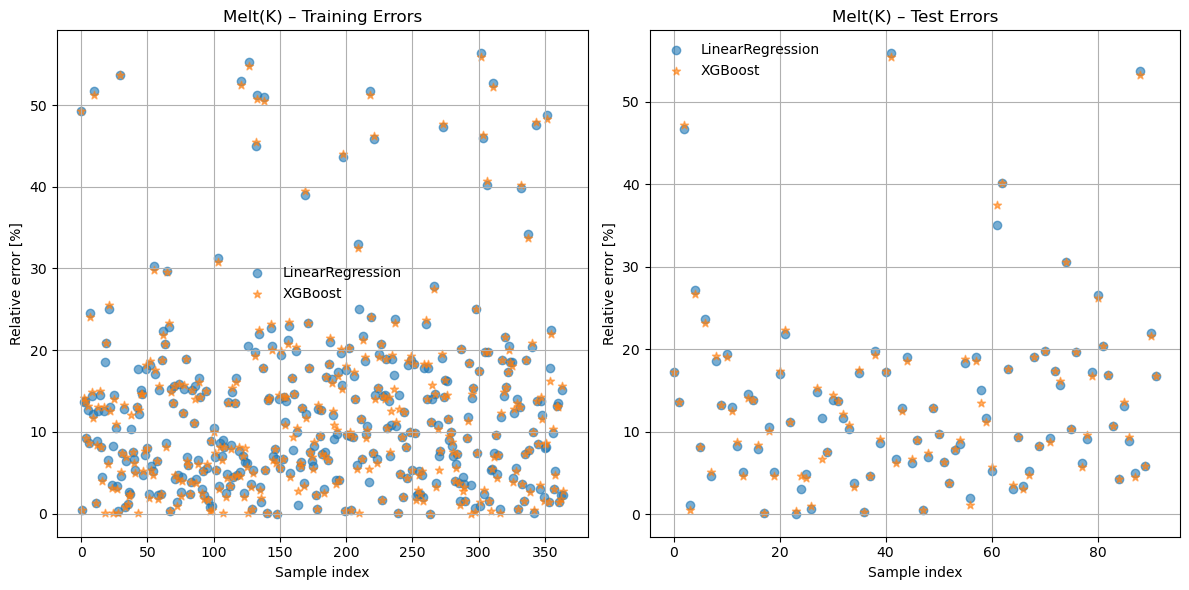

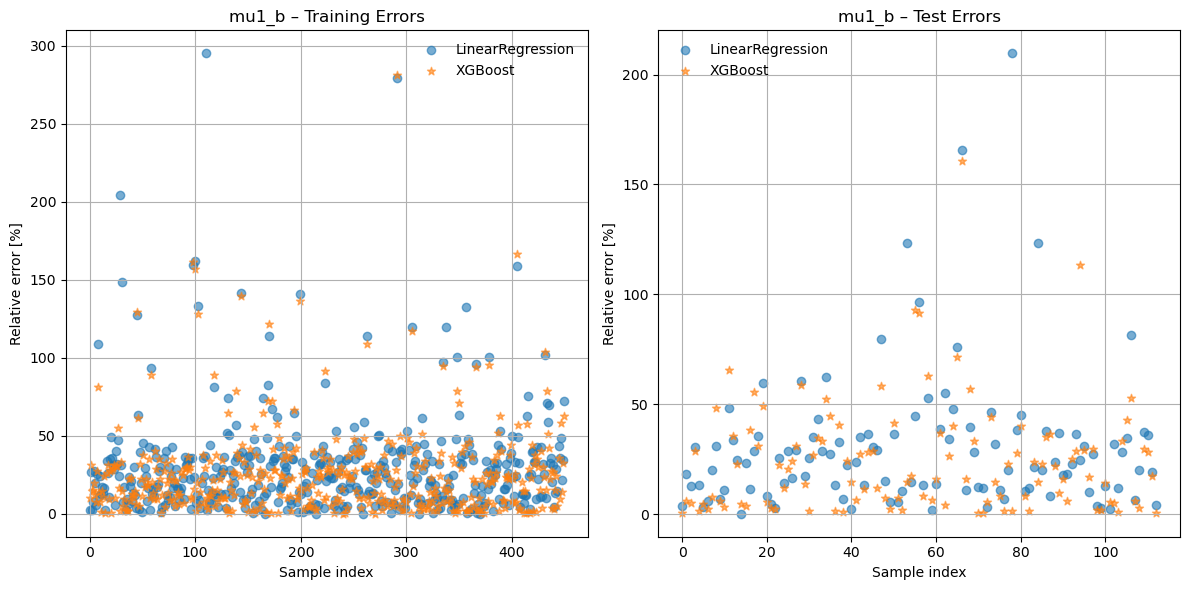

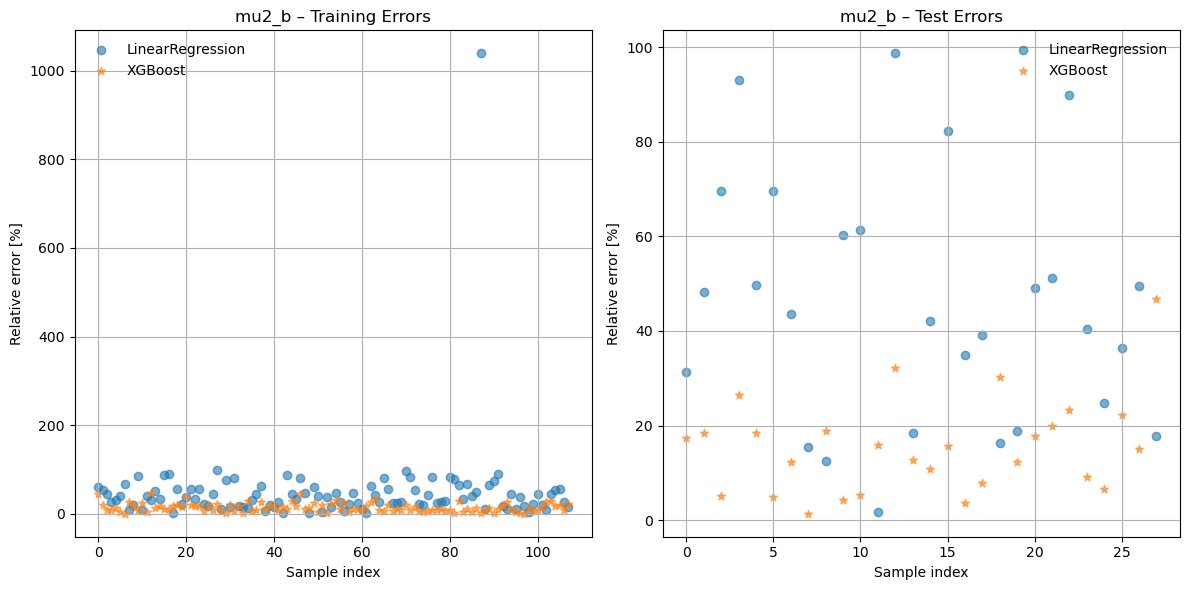

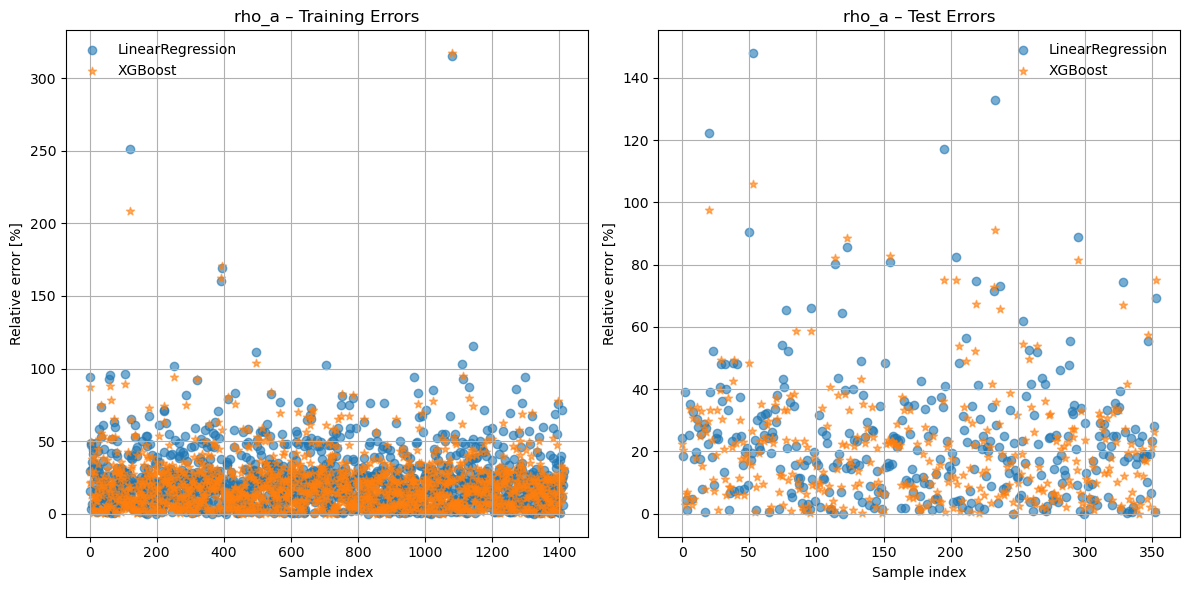

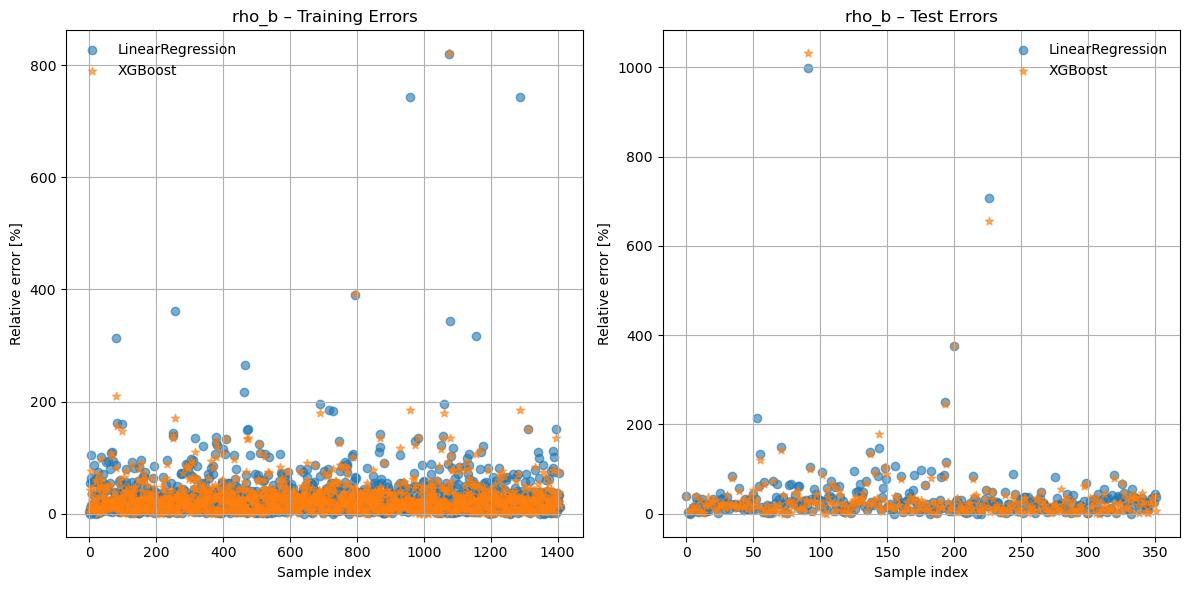

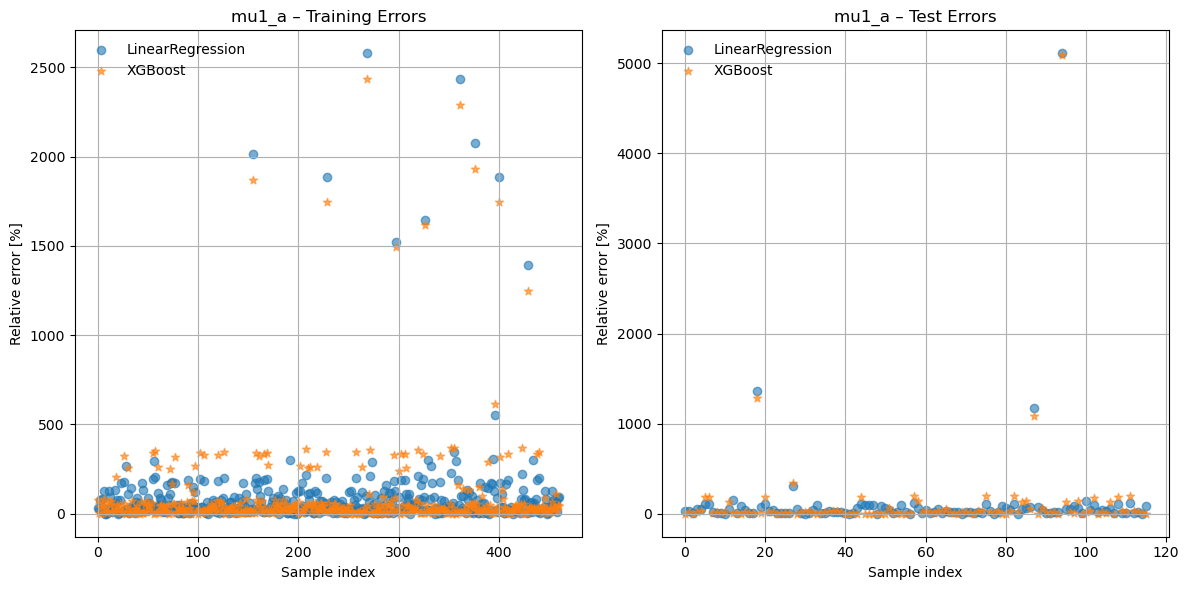

/var/folders/yw/ymf0hshn7hd1dkyly48rpl100000gn/T/ipykernel_65810/1579995455.py:222: RuntimeWarning: divide by zero encountered in divide
  rel_err = np.abs(y_true - y_pred) / np.abs(np.mean(y_true)) * 100


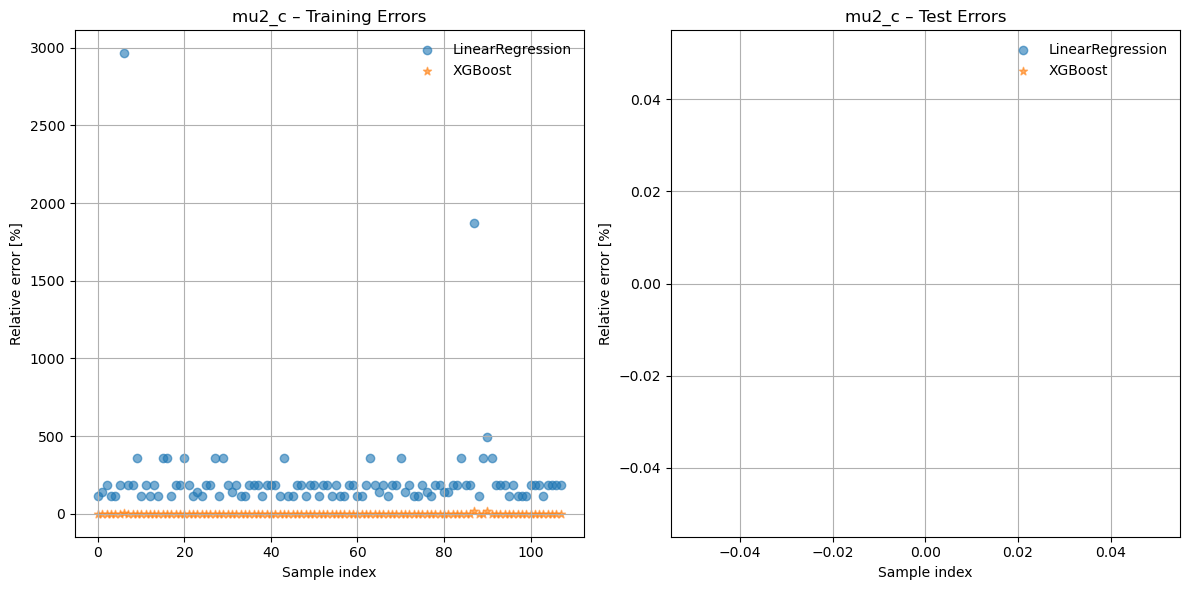

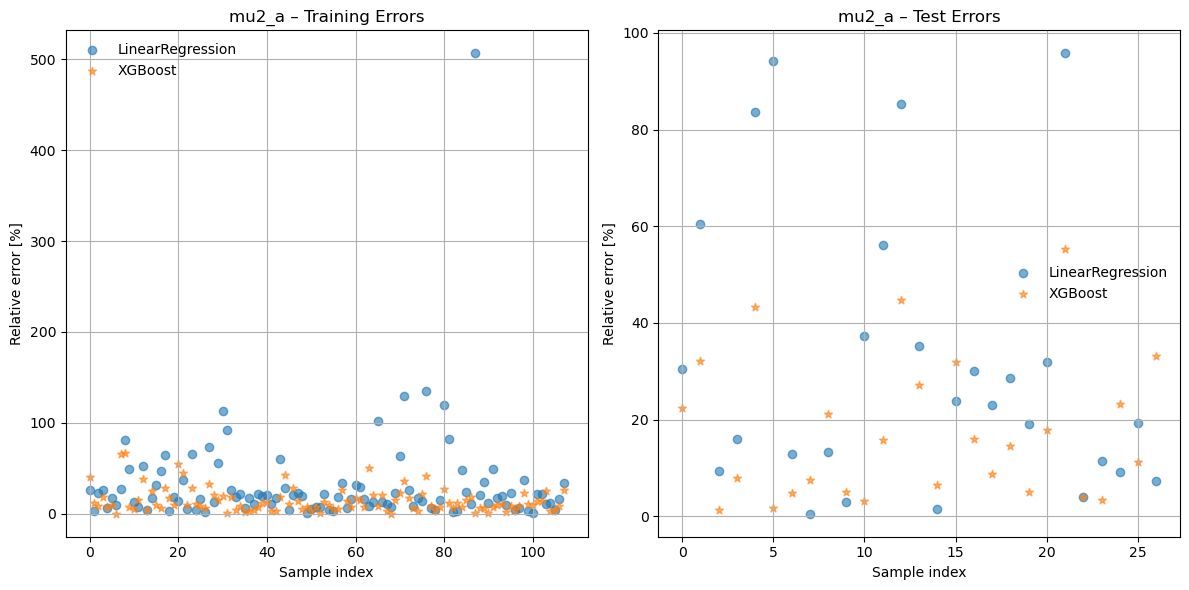


================ DATA USAGE SUMMARY ================

Melt(K)    | LinearRegression | target_vals= 457 | used= 457 | train= 365 | test=  92 | features=5
Melt(K)    | XGBoost          | target_vals= 457 | used= 457 | train= 365 | test=  92 | features=5
mu1_b      | LinearRegression | target_vals= 563 | used= 563 | train= 450 | test= 113 | features=3
mu1_b      | XGBoost          | target_vals= 563 | used= 563 | train= 450 | test= 113 | features=3
mu2_b      | LinearRegression | target_vals= 136 | used= 136 | train= 108 | test=  28 | features=3
mu2_b      | XGBoost          | target_vals= 136 | used= 136 | train= 108 | test=  28 | features=3
rho_a      | LinearRegression | target_vals=1769 | used=1769 | train=1415 | test= 354 | features=3
rho_a      | XGBoost          | target_vals=1769 | used=1769 | train=1415 | test= 354 | features=3
rho_b      | LinearRegression | target_vals=1759 | used=1759 | train=1407 | test= 352 | features=3
rho_b      | XGBoost          | target_vals=1759 | use

In [ ]:
import pandas as pd
import numpy as np
import ast
from collections import defaultdict
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import xgboost as xgb


# =========================================================
# 1. LOAD DATA
# =========================================================
df = pd.read_csv("/Users/meggie/Documents/MoltenSaltPropnet/data/new_mstdb_janz_with_ionic_polarizability.csv")

anion_filter = "Cl"

df = df[df["System"].astype(str).apply(lambda x: anion_filter in x)]
df = df.reset_index(drop=True)

print(f"Rows after Cl filter: {len(df)}")
# =========================================================
# 2. SAFE DICT → FLOAT
# =========================================================
def safe_eval(x):
    if pd.isna(x):
        return np.nan
    try:
        d = ast.literal_eval(x)
        if not isinstance(d, dict):
            return np.nan
        for k, v in d.items():
            if k != "Cl" and isinstance(v, (int, float)):
                return float(v)
        return np.nan
    except Exception:
        return np.nan


# =========================================================
# 3. FEATURE DEFINITIONS
# =========================================================
FEATURE_ID_TO_COL = {
    0: "polarizability_element[10-24Cm3]",
    1: "atomic_mass_element",
    2: "electronegativity_element",
    4: "atomic_radius_element[Angstrom]",
    5: "ionic_radius_element[Angstrom]",
    7: "first_ionization_energy[kJ_per_mol]"
}

TARGET_MAP = {
    0: ["Melt(K)", "Boil(K)", "mu1_b", "mu2_b", "k_a", "cp_a", "cp_b"],
    1: ["Melt(K)", "Boil(K)", "rho_a", "rho_b", "mu1_a", "mu2_b", "mu2_c", "k_b", "cp_a", "cp_b"],
    2: ["Melt(K)", "rho_a", "rho_b", "mu1_a", "mu2_b", "mu2_c", "k_b", "cp_a"],
    4: ["Boil(K)", "Melt(K)", "mu1_b", "mu2_a", "mu2_c", "k_a", "cp_b"],
    5: ["Boil(K)", "Melt(K)", "mu1_b", "k_b", "cp_b"],
    7: ["rho_a", "rho_b", "mu1_a", "mu2_a", "mu2_c", "k_b", "cp_a"]
}

TARGET_TO_FEATURE_IDS = defaultdict(list)
for fid, targets in TARGET_MAP.items():
    for t in targets:
        TARGET_TO_FEATURE_IDS[t].append(fid)


# =========================================================
# 4. APPLY safe_eval TO ATOMIC FEATURES
# =========================================================
for col in FEATURE_ID_TO_COL.values():
    if col in df.columns:
        df[col] = df[col].apply(safe_eval)


# =========================================================
# 5. CLEAN FEATURE NAMES (XGBOOST SAFE)
# =========================================================
def clean_feature_names(cols):
    return (
        cols
        .str.replace("[", "", regex=False)
        .str.replace("]", "", regex=False)
        .str.replace("<", "", regex=False)
        .str.replace(">", "", regex=False)
        .str.replace(" ", "_", regex=False)
    )

df.columns = clean_feature_names(df.columns)

FEATURE_ID_TO_COL_CLEAN = {
    fid: clean_feature_names(pd.Index([col]))[0]
    for fid, col in FEATURE_ID_TO_COL.items()
}


# =========================================================
# 6. MODELS
# =========================================================
MODELS = {
    "LinearRegression": LinearRegression(),
    "XGBoost": xgb.XGBRegressor(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
}


# =========================================================
# 7. TRAINING (STORE EVERYTHING)
# =========================================================
results = {}

print("\n================ TRAINING RESULTS ================\n")

for target in TARGET_TO_FEATURE_IDS:

    if target not in df.columns:
        continue

    feature_cols = [
        FEATURE_ID_TO_COL_CLEAN[fid]
        for fid in TARGET_TO_FEATURE_IDS[target]
        if fid in FEATURE_ID_TO_COL_CLEAN
        and FEATURE_ID_TO_COL_CLEAN[fid] in df.columns
    ]

    if not feature_cols:
        continue

    X = df[feature_cols]
    y = df[target]

    # rows used for this target
    mask = y.notna() & X.notna().any(axis=1)
    X_use = X.loc[mask]
    y_use = y.loc[mask]

    # drop empty features
    X_use = X_use.loc[:, X_use.notna().any(axis=0)]

    if X_use.shape[1] == 0 or len(y_use) < 20:
        continue

    X_train, X_test, y_train, y_test = train_test_split(
        X_use, y_use, test_size=0.2, random_state=42
    )

    results[target] = {}

    for name, model in MODELS.items():
        model.fit(X_train, y_train)

        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        rmse = mean_squared_error(y_test, y_pred_test) ** 0.5

        results[target][name] = {
            "rmse": rmse,
            "y_train": y_train.values,
            "y_pred_train": y_pred_train,
            "y_test": y_test.values,
            "y_pred_test": y_pred_test,
            "n_total_target": df[target].notna().sum(),
            "n_used": len(y_use),
            "n_train": len(y_train),
            "n_test": len(y_test),
            "features_used": X_use.columns.tolist()
        }

        print(
            f"{target:10s} | {name:16s} | RMSE={rmse:.3f} | "
            f"used={len(y_use)} (train={len(y_train)}, test={len(y_test)})"
        )


# =========================================================
# 8. ERROR PLOT FUNCTION
# =========================================================
def error_plot(results, target):
    plt.figure(figsize=(12, 6))

    marker_styles = {
        "LinearRegression": "o",
        "XGBoost": "*"
    }

    # -------- Training --------
    plt.subplot(1, 2, 1)
    for model_name in results[target]:
        y_true = results[target][model_name]["y_train"]
        y_pred = results[target][model_name]["y_pred_train"]

        rel_err = np.abs(y_true - y_pred) / np.abs(np.mean(y_true)) * 100

        plt.scatter(
            np.arange(len(y_true)),
            rel_err,
            alpha=0.6,
            marker=marker_styles.get(model_name, "o"),
            label=model_name
        )

    plt.title(f"{target} – Training Errors")
    plt.xlabel("Sample index")
    plt.ylabel("Relative error [%]")
    plt.grid(True)
    plt.legend(frameon=False)

    # -------- Testing --------
    plt.subplot(1, 2, 2)
    for model_name in results[target]:
        y_true = results[target][model_name]["y_test"]
        y_pred = results[target][model_name]["y_pred_test"]

        rel_err = np.abs(y_true - y_pred) / np.abs(np.mean(y_true)) * 100

        plt.scatter(
            np.arange(len(y_true)),
            rel_err,
            alpha=0.6,
            marker=marker_styles.get(model_name, "o"),
            label=model_name
        )

    plt.title(f"{target} – Test Errors")
    plt.xlabel("Sample index")
    plt.ylabel("Relative error [%]")
    plt.grid(True)
    plt.legend(frameon=False)

    plt.tight_layout()
    plt.show()


# =========================================================
# 9. GENERATE ERROR PLOTS
# =========================================================
for target in results:
    error_plot(results, target)


# =========================================================
# 10. DATA USAGE SUMMARY (VERY IMPORTANT)
# =========================================================
print("\n================ DATA USAGE SUMMARY ================\n")
for target in results:
    for model in results[target]:
        r = results[target][model]
        print(
            f"{target:10s} | {model:16s} | "
            f"target_vals={r['n_total_target']:4d} | "
            f"used={r['n_used']:4d} | "
            f"train={r['n_train']:4d} | "
            f"test={r['n_test']:4d} | "
            f"features={len(r['features_used'])}"
        )
